### Table of Contents
1. Setup

2. Load & understanding record dataset

3. Data Analysis & EDA record dataset

4. Load & understanding client dataset

5. Data analysis & EDA client dataset

6. Dataset merging and analysis

7. EDA of merged dataset

8. Data Preprocessing 

9.  Model building

10. Hypothesis & Feature Engineering

11. Model Evaluation

    



### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, precision_score, recall_score,f1_score
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier






import warnings
warnings.filterwarnings('ignore')

The code imports the libraries used throughout the notebook (pandas/numpy for data handling, matplotlib/seaborn for plots, scikit-learn for preprocessing and modelling) and silences warnings so output stays readable. Keeping every import in one cell at the top makes the notebook's dependencies explicit and lets it run top-to-bottom without hidden import errors later on.

### Load & data understanding of record dataset

In [2]:
record = pd.read_csv("Record.csv")
print(record.shape)

(100000, 51)


Loads the "record" dataset and prints its shape.
Result indicate 100,000 rows and 51 columns

### Exploratory Data Analysis (EDA) of record dataset




In [3]:
record.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


the function previews the first 5 rows of the record dataset.
This is a quick sanity check that the CSV loaded correctly and the columns look like the numeric usage metrics we expect (revenue, minutes, overage, etc.) before doing any real analysis.

In [4]:
record.dtypes

rev_Mean           float64
mou_Mean           float64
totmrc_Mean        float64
da_Mean            float64
ovrmou_Mean        float64
ovrrev_Mean        float64
vceovr_Mean        float64
datovr_Mean        float64
roam_Mean          float64
change_mou         float64
change_rev         float64
drop_vce_Mean      float64
drop_dat_Mean      float64
blck_vce_Mean      float64
blck_dat_Mean      float64
unan_vce_Mean      float64
unan_dat_Mean      float64
plcd_vce_Mean      float64
plcd_dat_Mean      float64
recv_vce_Mean      float64
recv_sms_Mean      float64
comp_vce_Mean      float64
comp_dat_Mean      float64
custcare_Mean      float64
ccrndmou_Mean      float64
cc_mou_Mean        float64
inonemin_Mean      float64
threeway_Mean      float64
mou_cvce_Mean      float64
mou_cdat_Mean      float64
mou_rvce_Mean      float64
owylis_vce_Mean    float64
mouowylisv_Mean    float64
iwylis_vce_Mean    float64
mouiwylisv_Mean    float64
peak_vce_Mean      float64
peak_dat_Mean      float64
m

Here we lists the dtype of every column.
All 51 columns are numeric, no type coercion is needed and every column is a candidate for statistical/correlation analysis straight away.

In [5]:
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 51 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   rev_Mean         99643 non-null   float64
 1   mou_Mean         99643 non-null   float64
 2   totmrc_Mean      99643 non-null   float64
 3   da_Mean          99643 non-null   float64
 4   ovrmou_Mean      99643 non-null   float64
 5   ovrrev_Mean      99643 non-null   float64
 6   vceovr_Mean      99643 non-null   float64
 7   datovr_Mean      99643 non-null   float64
 8   roam_Mean        99643 non-null   float64
 9   change_mou       99109 non-null   float64
 10  change_rev       99109 non-null   float64
 11  drop_vce_Mean    100000 non-null  float64
 12  drop_dat_Mean    100000 non-null  float64
 13  blck_vce_Mean    100000 non-null  float64
 14  blck_dat_Mean    100000 non-null  float64
 15  unan_vce_Mean    100000 non-null  float64
 16  unan_dat_Mean    100000 non-null  float

.info() gives a compact summary of non-null counts, dtypes and memory footprint in one call.
The dataset uses 38.9MB of memory and 11 of the 51 columns have missing values, this is the first signal that a missing-value strategy will be needed before modelling.

In [6]:
record.isnull().sum()

rev_Mean           357
mou_Mean           357
totmrc_Mean        357
da_Mean            357
ovrmou_Mean        357
ovrrev_Mean        357
vceovr_Mean        357
datovr_Mean        357
roam_Mean          357
change_mou         891
change_rev         891
drop_vce_Mean        0
drop_dat_Mean        0
blck_vce_Mean        0
blck_dat_Mean        0
unan_vce_Mean        0
unan_dat_Mean        0
plcd_vce_Mean        0
plcd_dat_Mean        0
recv_vce_Mean        0
recv_sms_Mean        0
comp_vce_Mean        0
comp_dat_Mean        0
custcare_Mean        0
ccrndmou_Mean        0
cc_mou_Mean          0
inonemin_Mean        0
threeway_Mean        0
mou_cvce_Mean        0
mou_cdat_Mean        0
mou_rvce_Mean        0
owylis_vce_Mean      0
mouowylisv_Mean      0
iwylis_vce_Mean      0
mouiwylisv_Mean      0
peak_vce_Mean        0
peak_dat_Mean        0
mou_peav_Mean        0
mou_pead_Mean        0
opk_vce_Mean         0
opk_dat_Mean         0
mou_opkv_Mean        0
mou_opkd_Mean        0
drop_blk_Me

We checked the missing values per column. 9 columns are missing exactly 357 values and 2 columns (change_mou, change_rev) are missing 891, the uniform counts suggest these are the same subset of rows missing several fields together (likely new customers with no prior-period data to compute a change from), rather than random missingness.


In [7]:
# correlation analysis
target_col = 'churn'  
numeric_df = record.select_dtypes(include=[np.number])
if target_col not in numeric_df.columns:
    numeric_df[target_col] = record[target_col].astype(int)
churn_corr = numeric_df.corr()[target_col].drop(target_col).sort_values(ascending=False)
print(churn_corr)

vceovr_Mean        0.024240
ovrrev_Mean        0.023736
months             0.020991
ovrmou_Mean        0.019720
roam_Mean          0.009324
change_rev         0.007832
recv_sms_Mean     -0.000812
datovr_Mean       -0.001290
callfwdv_Mean     -0.002248
blck_dat_Mean     -0.004016
unan_dat_Mean     -0.004727
mou_pead_Mean     -0.005566
drop_dat_Mean     -0.006223
peak_dat_Mean     -0.007580
mou_cdat_Mean     -0.008252
mou_opkd_Mean     -0.008366
comp_dat_Mean     -0.008882
opk_dat_Mean      -0.008898
blck_vce_Mean     -0.009023
plcd_dat_Mean     -0.009499
rev_Mean          -0.010883
da_Mean           -0.013551
drop_vce_Mean     -0.015261
drop_blk_Mean     -0.015851
threeway_Mean     -0.030657
callwait_Mean     -0.031082
change_mou        -0.031536
inonemin_Mean     -0.034506
mouowylisv_Mean   -0.034914
mouiwylisv_Mean   -0.035021
cc_mou_Mean       -0.035248
unan_vce_Mean     -0.035560
custcare_Mean     -0.036393
ccrndmou_Mean     -0.037890
iwylis_vce_Mean   -0.040853
recv_vce_Mean     -0

Given the structure of the dataset, this correlation matrix is difficult to interpret. Target column correlation is more appropriate. The results indicate that correlation is essentially flat across the board. The strongest value here is totmrc_Mean at -0.069, and the highest positive is vceovr_Mean at 0.024. On a -1 to +1 scale, these are negligible none of the 51 features has a meaningful linear relationship with churn individually.

In [8]:
stats = record.describe().T
stats

,count,mean,std,min,25%,50%,75%,max
rev_Mean,99643.0,5.871998e+01,46.291677,-6.167500e+00,3.326000e+01,4.819500e+01,7.075000e+01,3.843262e+03
mou_Mean,99643.0,5.135599e+02,525.168140,0.000000e+00,1.507500e+02,3.555000e+02,7.030000e+02,1.220675e+04
totmrc_Mean,99643.0,4.617914e+01,23.623489,-2.691500e+01,3.000000e+01,4.499000e+01,5.999000e+01,4.099900e+02
da_Mean,99643.0,8.888279e-01,2.177619,0.000000e+00,0.000000e+00,2.475000e-01,9.900000e-01,1.593900e+02
ovrmou_Mean,99643.0,4.107225e+01,97.296150,0.000000e+00,0.000000e+00,2.750000e+00,4.200000e+01,4.320750e+03
ovrrev_Mean,99643.0,1.355956e+01,30.500885,0.000000e+00,0.000000e+00,1.000000e+00,1.443750e+01,1.102400e+03
vceovr_Mean,99643.0,1.329506e+01,30.056089,0.000000e+00,0.000000e+00,6.825000e-01,1.402500e+01,8.960875e+02
datovr_Mean,99643.0,2.613177e-01,3.126531,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.235400e+02
roam_Mean,99643.0,1.286405e+00,14.711374,0.000000e+00,0.000000e+00,0.000000e+00,2.350000e-01,3.685200e+03
change_mou,99109.0,-1.393382e+01,276.087509,-3.875000e+03,-8.700000e+01,-6.250000e+00,6.300000e+01,3.121925e+04


 .describe().T gives summary statistics (mean, std, min/max, quartiles) for every numeric column. Churn is close to a 50/50 split and most usage features are heavily right-skewed with extreme max values relative to their mean, this both explains why the linear correlations above were flat (skew and outliers dampen Pearson correlation) and justifies using the median rather than the mean for imputation, since the median is robust to that skew.

#### Handling Missing Values on record dataset

In [9]:
# Handling Missing Values 
cols_to_impute = ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
                   'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean',
                   'change_mou', 'change_rev']

for col in cols_to_impute:
    median_val = record[col].median()
    record[col] = record[col].fillna(median_val)

# Verify no missing values remain
print(record[cols_to_impute].isnull().sum())

rev_Mean       0
mou_Mean       0
totmrc_Mean    0
da_Mean        0
ovrmou_Mean    0
ovrrev_Mean    0
vceovr_Mean    0
datovr_Mean    0
roam_Mean      0
change_mou     0
change_rev     0
dtype: int64


The missing values in the 11 columns were filled using each column's own median. Median imputation was chosen (over mean) specifically because the EDA above showed heavy skew/outliers, where the mean would be pulled away from the "typical" value. Result: Confirms all 11 columns now show 0 missing values.

#### Checking Outliers on record dataset

In [10]:
# Numeric columns to check (exclude ID and target)
numeric_cols = record.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Customer_ID', 'churn']
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

outlier_summary = []

for col in numeric_cols:
    Q1 = record[col].quantile(0.25)
    Q3 = record[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((record[col] < lower_bound) | (record[col] > upper_bound)).sum()
    pct_outliers = 100 * n_outliers / len(record)

    outlier_summary.append({
        'column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
print(outlier_df.to_string(index=False))

         column         Q1         Q3        IQR  lower_bound  upper_bound  n_outliers  pct_outliers
     change_rev  -7.203125   1.545000   8.748125   -20.325312    14.667187       26325        26.325
      roam_Mean   0.000000   0.235000   0.235000    -0.352500     0.587500       18914        18.914
  plcd_dat_Mean   0.000000   0.000000   0.000000     0.000000     0.000000       14980        14.980
  callwait_Mean   0.000000   1.333333   1.333333    -2.000000     3.333333       14305        14.305
    cc_mou_Mean   0.000000   2.873333   2.873333    -4.310000     7.183333       14265        14.265
     change_mou -86.000000  61.750000 147.750000  -307.625000   283.375000       13768        13.768
    datovr_Mean   0.000000   0.000000   0.000000     0.000000     0.000000       13673        13.673
        da_Mean   0.000000   0.742500   0.742500    -1.113750     1.856250       13643        13.643
  ccrndmou_Mean   0.000000   4.000000   4.000000    -6.000000    10.000000       13456     

Outliers per column were checked using the IQR rule (1.5×IQR beyond Q1/Q3). IQR flags anywhere from 0.433% to 26.325% of rows as outliers depending on the column. The columns with the highest rates (e.g. `change_rev`, `roam_Mean`, `plcd_dat_Mean`) are heavily zero-inflated, so IQR is misleadingly flagging "a customer who actually used the service" as an outlier just because most customers reported zero. This is a sign IQR isn't reliable for this data.

In [11]:
from scipy import stats
z_outlier_summary = []

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(record[col], nan_policy='omit'))
    n_outliers = (z_scores > 3).sum()
    pct_outliers = 100 * n_outliers / len(record)

    z_outlier_summary.append({
        'column': col,
        'n_outliers_z3': n_outliers,
        'pct_outliers_z3': pct_outliers
    })

z_outlier_df = pd.DataFrame(z_outlier_summary).sort_values('pct_outliers_z3', ascending=False)
print(z_outlier_df.to_string(index=False))

         column  n_outliers_z3  pct_outliers_z3
  mou_opkv_Mean           2307            2.307
  mou_rvce_Mean           2124            2.124
   opk_vce_Mean           1994            1.994
iwylis_vce_Mean           1986            1.986
  mou_cvce_Mean           1969            1.969
  mou_peav_Mean           1947            1.947
mouiwylisv_Mean           1940            1.940
    vceovr_Mean           1935            1.935
mouowylisv_Mean           1931            1.931
owylis_vce_Mean           1929            1.929
    ovrrev_Mean           1913            1.913
  drop_vce_Mean           1895            1.895
  peak_vce_Mean           1872            1.872
  unan_vce_Mean           1866            1.866
  plcd_vce_Mean           1825            1.825
  comp_vce_Mean           1821            1.821
       mou_Mean           1819            1.819
  complete_Mean           1815            1.815
   attempt_Mean           1814            1.814
    ovrmou_Mean           1810          

Here we repeated the outlier check using the z-score method instead of IQR. Z-score gives a much tighter, more consistent 0.077% to 2.307% outlier rate across columns, without being thrown off by the zero-inflated columns the way IQR was.  this means preferring z-score is more reliable outlier signal for this dataset.

### Load & data understanding of record dataset

In [12]:
client = pd.read_csv("Client.csv")
print(client.shape)

(100000, 50)


client dataset have 100.000 rows and 50 columns

### EDA and analysis of client dataset

In [13]:
client.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


This result confirms the data loaded correctly and shows this dataset carries a different type of information from the record dataset, subscriber/account counts, credit class and demographic-style fields

In [14]:
client.dtypes

uniqsubs              int64
actvsubs              int64
new_cell             object
crclscod             object
asl_flag             object
totcalls              int64
totmou              float64
totrev              float64
adjrev              float64
adjmou              float64
adjqty                int64
avgrev              float64
avgmou              float64
avgqty              float64
avg3mou               int64
avg3qty               int64
avg3rev               int64
avg6mou             float64
avg6qty             float64
avg6rev             float64
prizm_social_one     object
area                 object
dualband             object
refurb_new           object
hnd_price           float64
phones              float64
models              float64
hnd_webcap           object
truck               float64
rv                  float64
ownrent              object
lor                 float64
dwlltype             object
marital              object
adults              float64
infobase            

Unlike the record dataset, this one is a mix of numeric and object (categorical/text) columns. For example new_cell, crclscod, asl_flag, this means these columns will need categorical encoding before machine learning.

In [15]:
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100

All 50 columns report 100,000 non-null here at the top of the printout, but the missing-value breakdown below shows several columns do have missing values. 

In [16]:
missing = pd.DataFrame({
    'Missing': client.isnull().sum(),
    'Percentage': client.isnull().mean() * 100
}).sort_values('Missing', ascending=False)

missing

,Missing,Percentage
numbcars,49366,49.366
dwllsize,38308,38.308
HHstatin,37923,37.923
ownrent,33706,33.706
dwlltype,31909,31.909
lor,30190,30.190
income,25436,25.436
adults,23019,23.019
infobase,22079,22.079
hnd_webcap,10189,10.189


Missingness is far from uniform, numbcars is missing in 49% of rows, dwllsize/HHstatin/ownrent/dwlltype in 32 to 38%, down to under 1% for most usage columns. That pattern (a cluster of demographic/property fields all missing together) suggests the missingness itself may carry information (e.g. "no property data available for this customer") rather than being random. This means it is more helpfull to encoding as a flag rather than just imputing over it.

# Dataset Merging and analysis

### dataset pre-merging check

In [17]:
# Confirm the key exists and has the right dtype in both
print(record['Customer_ID'].dtype, client['Customer_ID'].dtype)


int64 int64


This confirms the join key Customer_ID has the same dtype in both datasets. A silent dtype mismatch (int64 vs object) is one of the most common causes of a merge quietly failing to match rows. 

In [18]:
# Check for duplicate keys in each dataset 
print("Record dataset duplicate Customer_IDs:", record['Customer_ID'].duplicated().sum())
print("Client dataset duplicate Customer_IDs:", client['Customer_ID'].duplicated().sum())


Record dataset duplicate Customer_IDs: 0
Client dataset duplicate Customer_IDs: 0


Here we checks each dataset for duplicate `Customer_ID` values.
Zero duplicates in either dataset, confirms that the key is unique per row in both. This is a required condition for a clean one-to-one merge.

In [19]:
# Check key overlap between the two datasets
ids_1 = set(record['Customer_ID'])
ids_2 = set(client['Customer_ID'])

print("record dataset row count:", len(record))
print("client dataset row count:", len(client))
print("IDs in both:", len(ids_1 & ids_2))
print("IDs only in record dataset:", len(ids_1 - ids_2))
print("IDs only in client dataset:", len(ids_2 - ids_1))

record dataset row count: 100000
client dataset row count: 100000
IDs in both: 100000
IDs only in record dataset: 0
IDs only in client dataset: 0


This means every Customer_ID exist in both datasets and no orphans exist on either side. This is a critical validation check before merge. With this either left join or inner join will procude the same results

In [20]:
# Merge datasets on the common key 'Customer_ID'
df = pd.merge(record, client, on='Customer_ID')
df.shape

(100000, 100)

the merged dataset have 100.000 rows and 100 columns confirming that the merge was successfull

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          100000 non-null  float64
 1   mou_Mean          100000 non-null  float64
 2   totmrc_Mean       100000 non-null  float64
 3   da_Mean           100000 non-null  float64
 4   ovrmou_Mean       100000 non-null  float64
 5   ovrrev_Mean       100000 non-null  float64
 6   vceovr_Mean       100000 non-null  float64
 7   datovr_Mean       100000 non-null  float64
 8   roam_Mean         100000 non-null  float64
 9   change_mou        100000 non-null  float64
 10  change_rev        100000 non-null  float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

In [22]:
print(df.isnull().sum())


rev_Mean          0
mou_Mean          0
totmrc_Mean       0
da_Mean           0
ovrmou_Mean       0
               ... 
kid6_10        1732
kid11_15       1732
kid16_17       1732
creditcd       1732
eqpdays           1
Length: 100, dtype: int64


Re-checks missing values on the merged dataset. The missingness patterns from both source datasets carry through the merge as expected (the kid* and creditcd columns still show 1,732 missing each) meaning nothing was introduced or lost by the merge itself.

In [23]:
from scipy import stats
z_outlier_summary = []

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    n_outliers = (z_scores > 3).sum()
    pct_outliers = 100 * n_outliers / len(df)

    z_outlier_summary.append({
        'column': col,
        'n_outliers_z3': n_outliers,
        'pct_outliers_z3': pct_outliers
    })

z_outlier_df = pd.DataFrame(z_outlier_summary).sort_values('pct_outliers_z3', ascending=False)
print(z_outlier_df.to_string(index=False))

         column  n_outliers_z3  pct_outliers_z3
  mou_opkv_Mean           2307            2.307
  mou_rvce_Mean           2124            2.124
   opk_vce_Mean           1994            1.994
iwylis_vce_Mean           1986            1.986
  mou_cvce_Mean           1969            1.969
  mou_peav_Mean           1947            1.947
mouiwylisv_Mean           1940            1.940
    vceovr_Mean           1935            1.935
mouowylisv_Mean           1931            1.931
owylis_vce_Mean           1929            1.929
    ovrrev_Mean           1913            1.913
  drop_vce_Mean           1895            1.895
  peak_vce_Mean           1872            1.872
  unan_vce_Mean           1866            1.866
  plcd_vce_Mean           1825            1.825
  comp_vce_Mean           1821            1.821
       mou_Mean           1819            1.819
  complete_Mean           1815            1.815
   attempt_Mean           1814            1.814
    ovrmou_Mean           1810          

Re-runs the z-score outlier check on the full merged dataset. Outlier rates on the merged data track closely with what was seen on the record dataset alone, confirming the merge didn't distort the underlying distributions.

# Exploratory Data analysis for the merged dataset

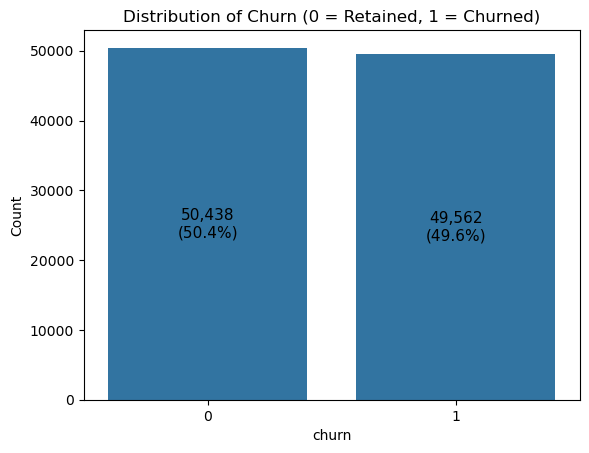

In [24]:
# Distribution of Churn
ax = sns.countplot(x='churn', data=record)
plt.title('Distribution of Churn (0 = Retained, 1 = Churned)')

total = len(record)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(
        f'{count:,}\n({pct:.1f}%)',
        (p.get_x() + p.get_width() / 2, p.get_height() / 2),
        ha='center', va='center', fontsize=11, color='black', fontweight='light'
    )

plt.ylabel('Count')
plt.show()

The plot shows distribution of customers who left and who stayed with the results indicating that churned customers 49.6% are just slightly below those retained 50.4%

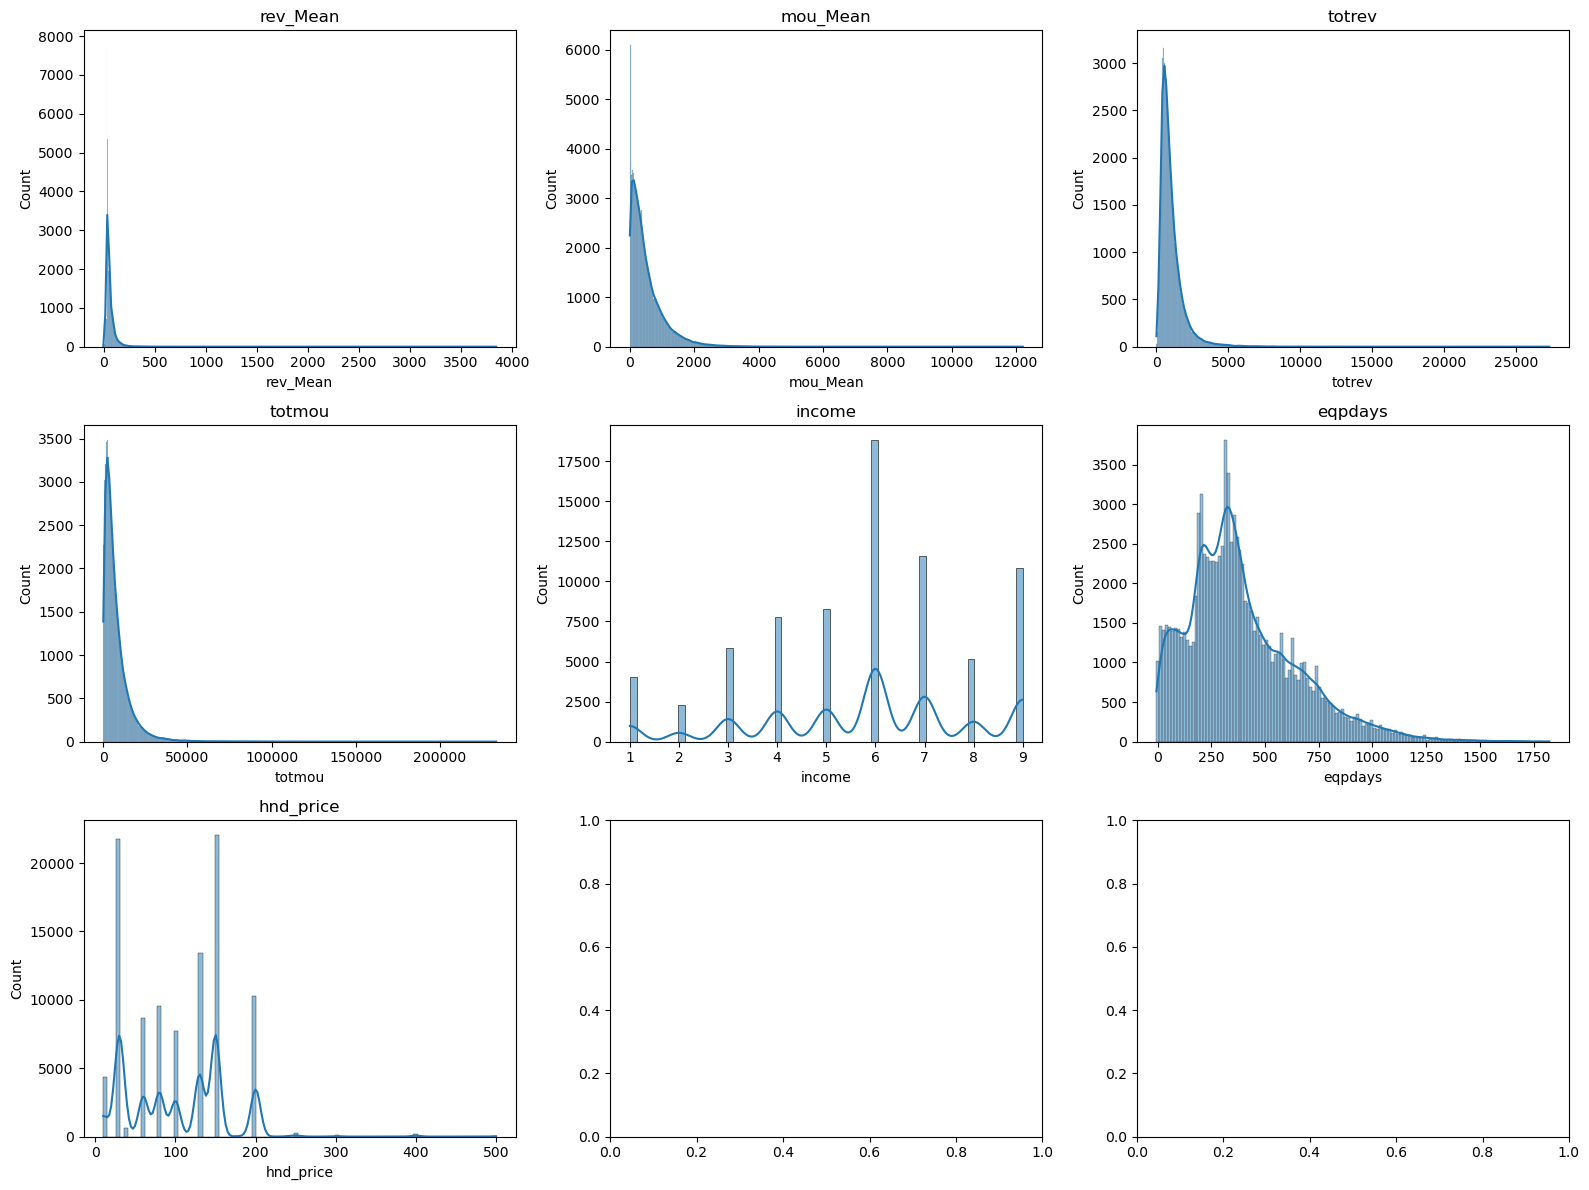

In [25]:
# Numeric distributions
numeric_cols = ['rev_Mean', 'mou_Mean', 'totrev', 'totmou', 'income', 'eqpdays', 'hnd_price']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

The results show histograms with KDE overlays for a handful of key numeric fields (revenue, minutes, income, equipment age, handset price). The plots shows a visual confirmation of the skewness these distributions are long-tailed rather than normal.

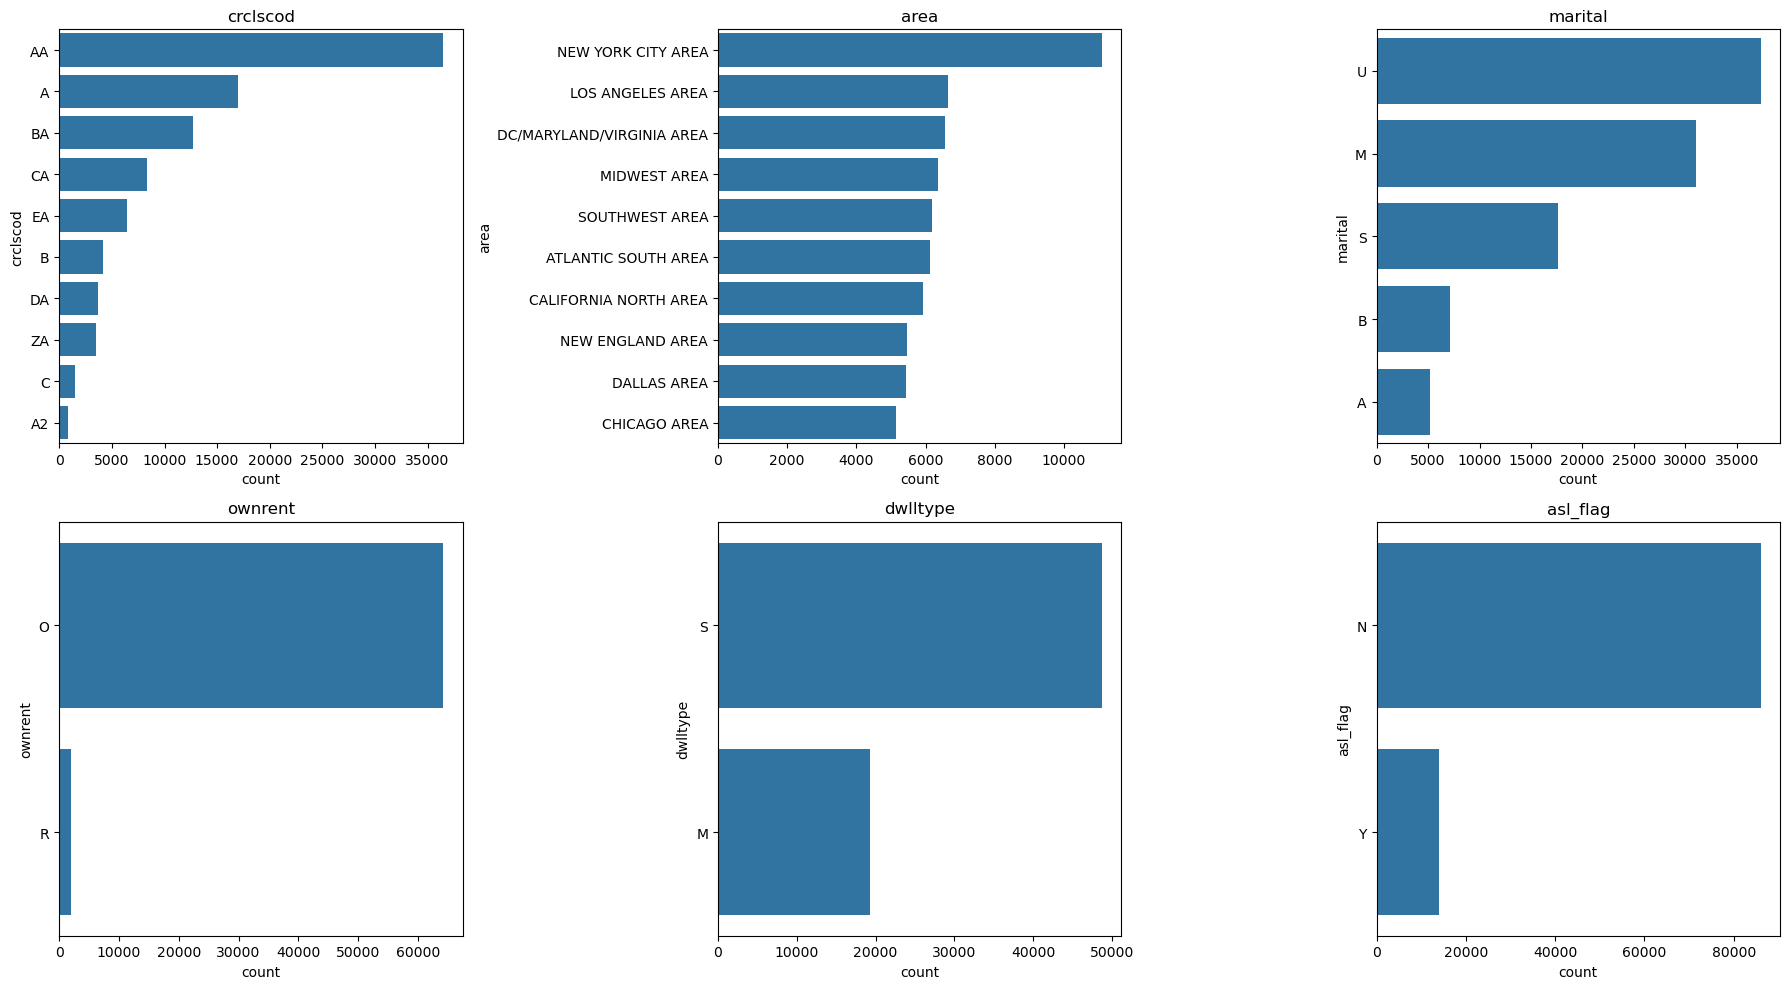

In [26]:
# Categorical distributions
cat_cols = ['crclscod', 'area', 'marital', 'ownrent', 'dwlltype', 'asl_flag']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index[:10]
    sns.countplot(y=col, data=df, order=order, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Here we have the bar charts of the top categories for six categorical columns (credit class, area, marital status, etc.). This gives a first look at how these categorical fields are distributed before they're encoded for modelling.

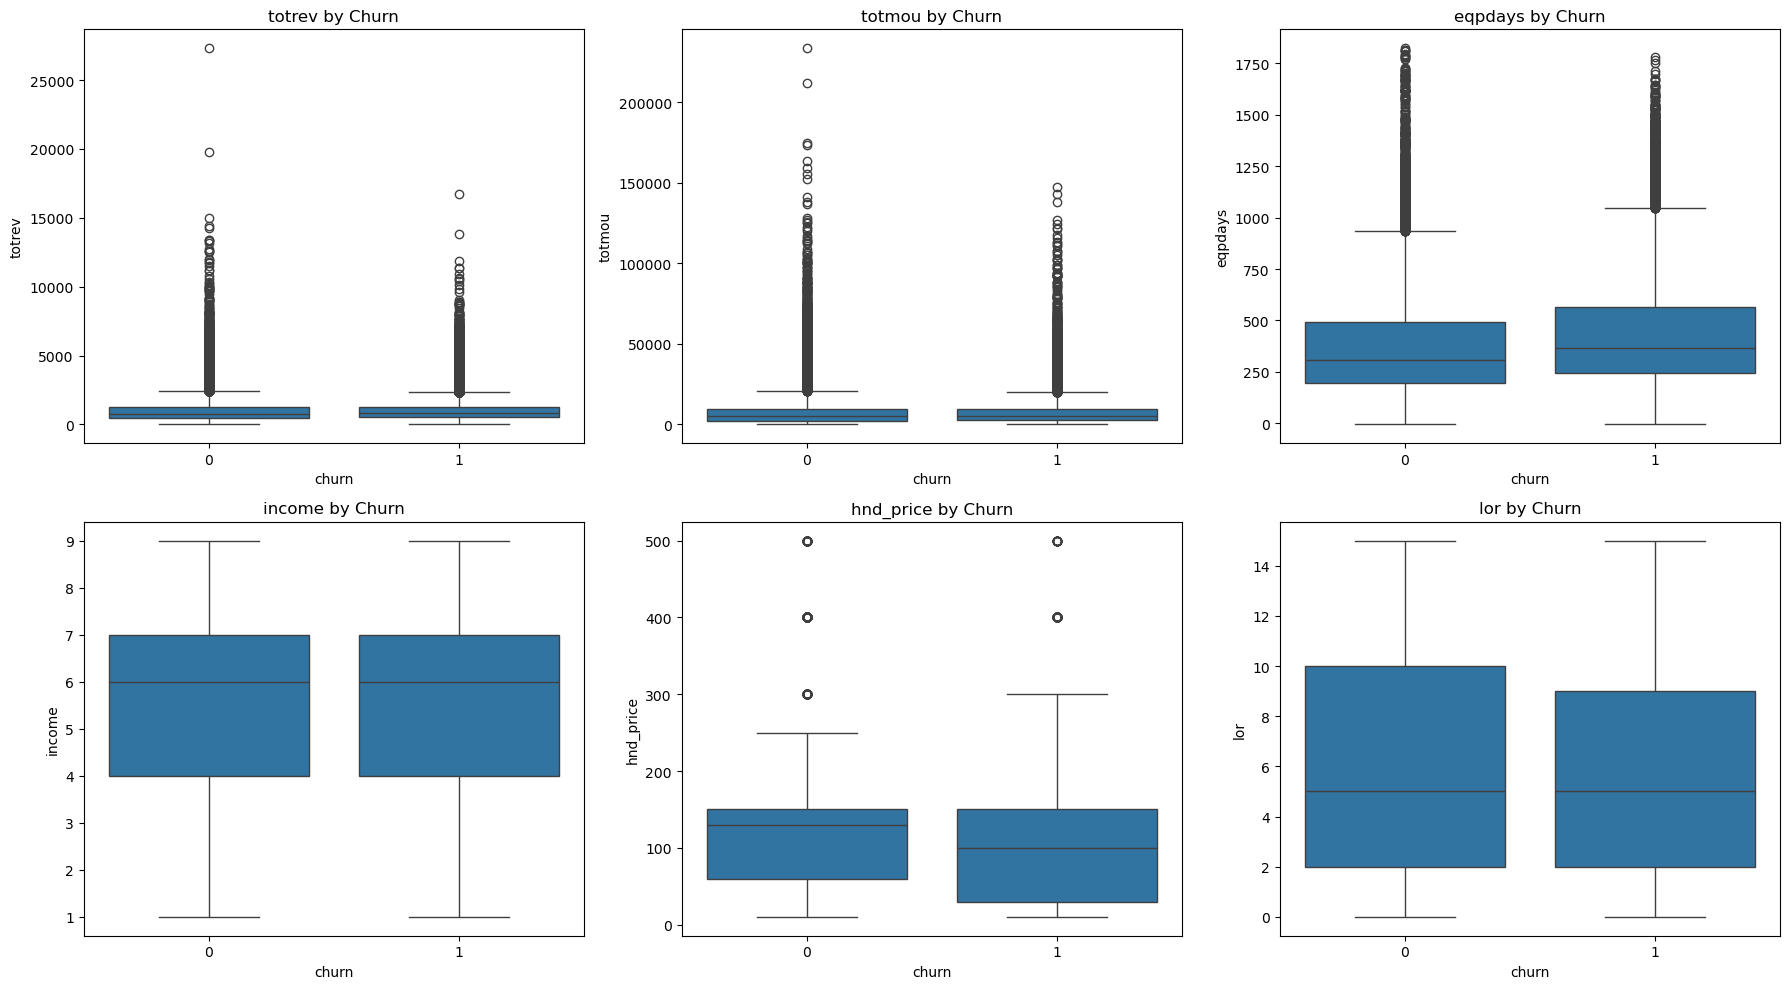

In [27]:
numeric_cols = ['totrev', 'totmou', 'eqpdays', 'income', 'hnd_price', 'lor']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

Here we have boxplots comparing churned vs retained customers across six numeric fields. This is just a visual, feature-by-feature look for separation between the two churn classes. This is useful for spotting candidate predictive features before formal feature selection is run later.



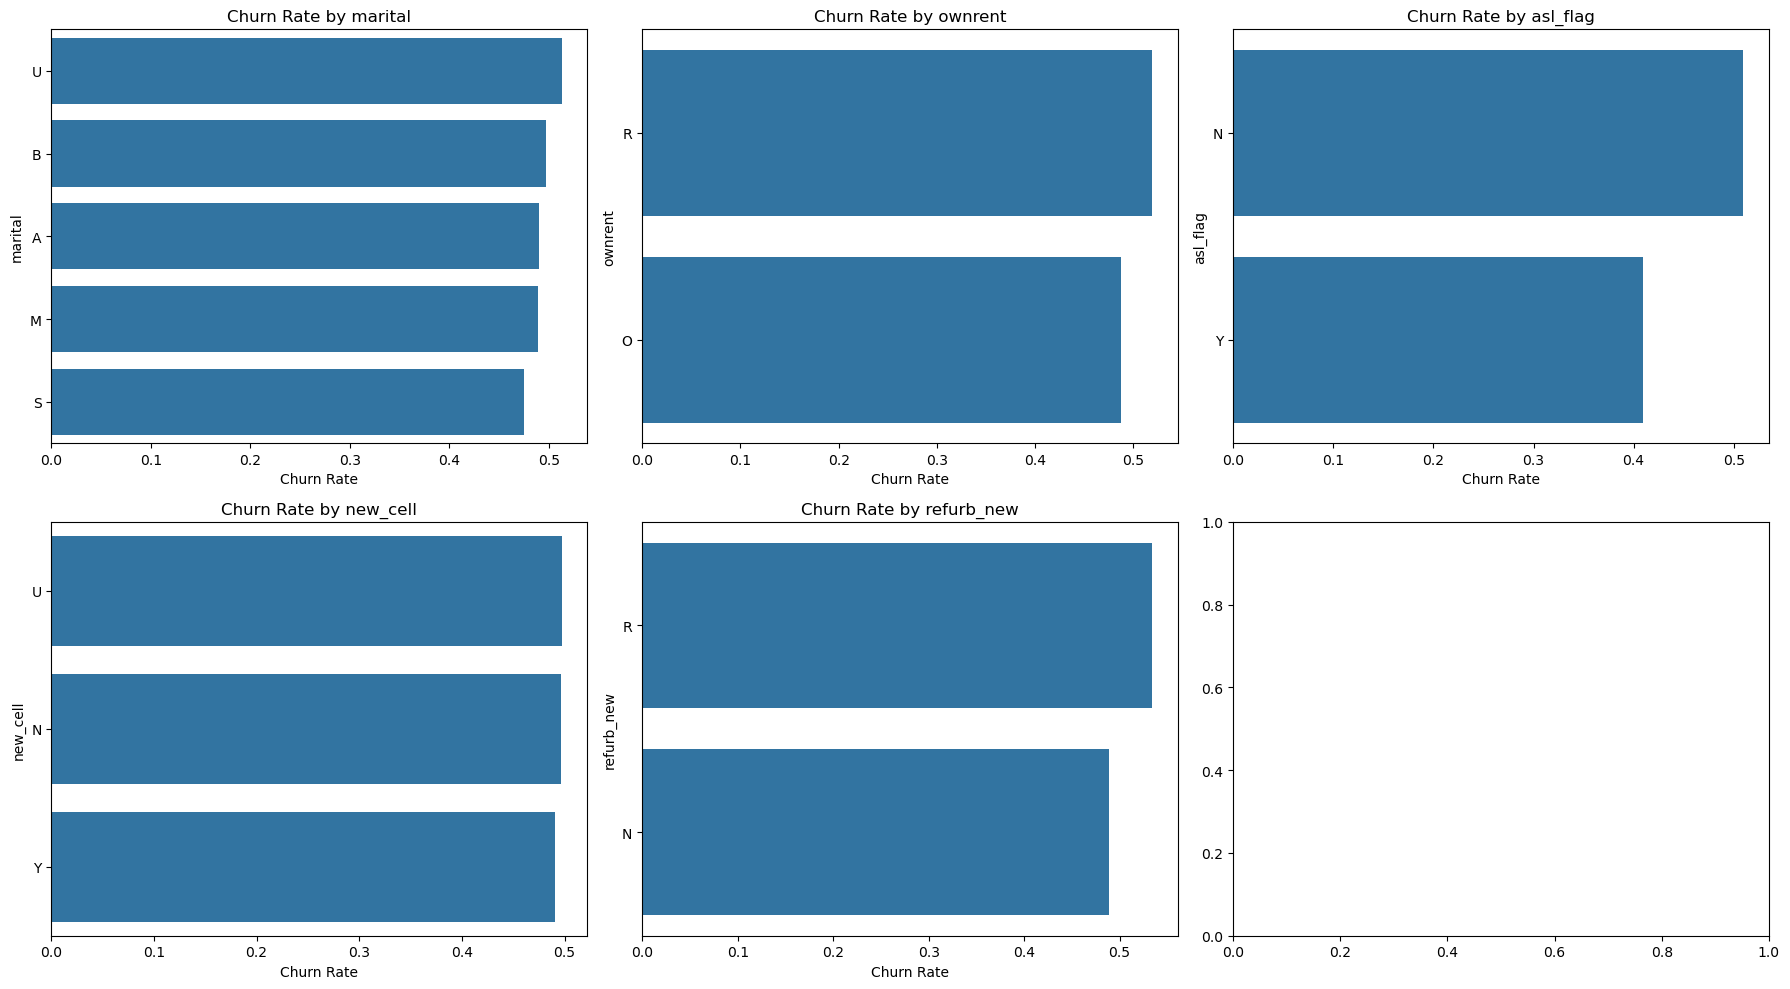

In [28]:
cat_cols = ['marital', 'ownrent', 'asl_flag', 'new_cell', 'refurb_new']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.values, y=churn_rate.index, ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('Churn Rate')
plt.tight_layout()
plt.show()

The bar charts of churn rate broken down by each category of five categorical fields (marital status, home ownership, spend-limit flag, new-cell flag, refurbished/new handset). Unlike the raw category-count charts above, this shows which specific category values are associated with higher or lower churn, a more direct signal for feature engineering than distribution alone.

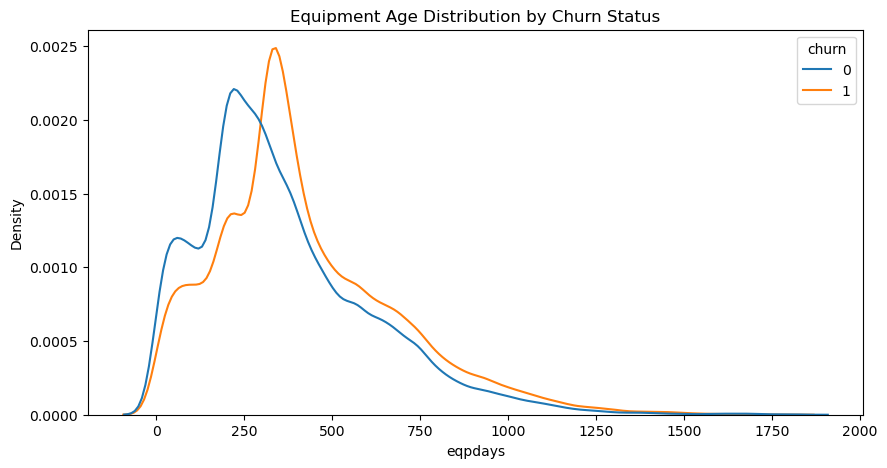

In [29]:
# churn rate by equipment age
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='eqpdays', hue='churn', common_norm=False)
plt.title('Equipment Age Distribution by Churn Status')
plt.savefig('eqpdays_churn_kde.png', bbox_inches='tight')
plt.show()

here we have a KDE plot of equipment age, split by churn status. If the churned-customer curve sits further right than the retained-customer curve, it indicates customers with older handsets churn more. 

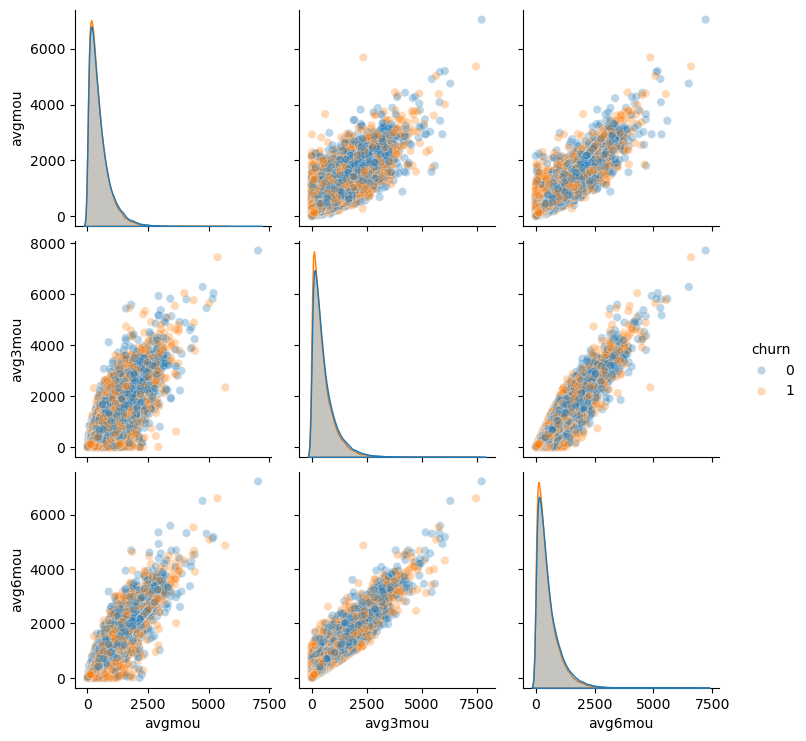

In [30]:
avg_mou_cols = ['avgmou', 'avg3mou', 'avg6mou']
sns.pairplot(df[avg_mou_cols + ['churn']].dropna(), hue='churn', diag_kind='kde', plot_kws={'alpha': 0.3})
plt.show()

The Pairplot of three related usage-average fields (avgmou, avg3mou, avg6mou) coloured by churn. This checks whether short-term vs long-term average usage windows separate churners from non-churners differently, and whether the three windows are highly correlated with each other. 

### Feature Engineering 
Initial data understanding indicated that these datasets have a lot features with cryptic names and no business context. Feature engineering is therefore required to create business readable features 

In [31]:
rename_map = {
    # Usage / revenue (dataset 1)
    'rev_Mean': 'monthly_revenue',
    'mou_Mean': 'monthly_minutes',
    'totmrc_Mean': 'monthly_recurring_charge',
    'da_Mean': 'directory_assist_calls',
    'ovrmou_Mean': 'overage_minutes',
    'ovrrev_Mean': 'overage_revenue',
    'vceovr_Mean': 'voice_overage_revenue',
    'datovr_Mean': 'data_overage_revenue',
    'roam_Mean': 'roaming_calls',
    'change_mou': 'mou_percent_change',
    'change_rev': 'rev_percent_change',

    # Call outcomes
    'drop_vce_Mean': 'dropped_voice_calls',
    'drop_dat_Mean': 'dropped_data_calls',
    'blck_vce_Mean': 'blocked_voice_calls',
    'blck_dat_Mean': 'blocked_data_calls',
    'unan_vce_Mean': 'unanswered_voice_calls',
    'unan_dat_Mean': 'unanswered_data_calls',
    'plcd_vce_Mean': 'attempted_voice_calls',
    'plcd_dat_Mean': 'attempted_data_calls',
    'recv_vce_Mean': 'received_voice_calls',
    'recv_sms_Mean': 'received_sms',                     
    'comp_vce_Mean': 'completed_voice_calls',             
    'comp_dat_Mean': 'completed_data_calls',

    # Customer care
    'custcare_Mean': 'customer_care_calls',
    'ccrndmou_Mean': 'customer_care_rounded_minutes',
    'cc_mou_Mean': 'customer_care_unrounded_minutes',

    # Call type detail
    'inonemin_Mean': 'short_inbound_calls',
    'threeway_Mean': 'three_way_calls',
    'mou_cvce_Mean': 'completed_voice_minutes',
    'mou_cdat_Mean': 'completed_data_minutes',
    'mou_rvce_Mean': 'received_voice_minutes',
    'owylis_vce_Mean': 'outbound_wireless_calls',
    'mouowylisv_Mean': 'outbound_wireless_minutes',
    'iwylis_vce_Mean': 'inbound_wireless_calls',          
    'mouiwylisv_Mean': 'inbound_wireless_minutes',
    'peak_vce_Mean': 'peak_voice_calls',
    'peak_dat_Mean': 'peak_data_calls',
    'mou_peav_Mean': 'peak_voice_minutes',
    'mou_pead_Mean': 'peak_data_minutes',
    'opk_vce_Mean': 'off_peak_voice_calls',
    'opk_dat_Mean': 'off_peak_data_calls',
    'mou_opkv_Mean': 'off_peak_voice_minutes',
    'mou_opkd_Mean': 'off_peak_data_minutes',
    'drop_blk_Mean': 'dropped_blocked_calls',
    'attempt_Mean': 'total_attempted_calls',
    'complete_Mean': 'total_completed_calls',
    'callfwdv_Mean': 'call_forward_calls',
    'callwait_Mean': 'call_waiting_calls',

    # Target / tenure
    'churn': 'churn',                                     
    'months': 'months_in_service',

    # Household / subscriber
    'uniqsubs': 'unique_subscribers',
    'actvsubs': 'active_subscribers',
    'new_cell': 'new_cell_phone_user',
    'crclscod': 'credit_class_code',
    'asl_flag': 'account_spending_limit_flag',

    # Lifetime totals
    'totcalls': 'total_lifetime_calls',
    'totmou': 'total_lifetime_minutes',
    'totrev': 'total_lifetime_revenue',
    'adjrev': 'adj_lifetime_revenue',
    'adjmou': 'adj_lifetime_minutes',
    'adjqty': 'adj_lifetime_calls',
    'avgrev': 'avg_monthly_revenue_lifetime',
    'avgmou': 'avg_monthly_minutes_lifetime',
    'avgqty': 'avg_monthly_calls_lifetime',
    'avg3mou': 'avg_mou_last_3_months',
    'avg3qty': 'avg_calls_last_3_months',
    'avg3rev': 'avg_rev_last_3_months',
    'avg6mou': 'avg_mou_last_6_months',
    'avg6qty': 'avg_calls_last_6_months',
    'avg6rev': 'avg_rev_last_6_months',

    # Demographics / household 
    'prizm_social_one': 'social_group_code',
    'area': 'geographic_area',
    'dualband': 'dualband_handset',
    'refurb_new': 'handset_refurb_or_new',
    'hnd_price': 'handset_price',
    'phones': 'handsets_issued',
    'models': 'models_issued',
    'hnd_webcap': 'handset_web_capable',
    'truck': 'truck_indicator',
    'rv': 'rv_indicator',
    'ownrent': 'home_owner_or_renter',
    'lor': 'length_of_residence',
    'dwlltype': 'dwelling_type',
    'marital': 'marital_status',
    'adults': 'num_adults_household',
    'infobase': 'infobase_match',
    'income': 'estimated_income',
    'numbcars': 'num_vehicles',
    'HHstatin': 'household_status_indicator',
    'dwllsize': 'dwelling_size',
    'forgntvl': 'foreign_travel_flag',
    'ethnic': 'ethnicity_code',
    'kid0_2': 'child_0_2_flag',
    'kid3_5': 'child_3_5_flag',
    'kid6_10': 'child_6_10_flag',
    'kid11_15': 'child_11_15_flag',
    'kid16_17': 'child_16_17_flag',
    'creditcd': 'credit_card_indicator',
    'eqpdays': 'equipment_age_days',
    'Customer_ID': 'Customer_ID',                         
}

# Apply renaming
df = df.rename(columns=rename_map)
print(df.shape)

(100000, 100)


The original names have no inherent meaning to a reader and would make every chart, feature and finding harder to interpret and present, this single step makes the rest of the notebook self-explanatory. The shape stays at 100,000 × 100, confirming no columns were lost in the rename.

In [32]:

def safe_divide(numerator, denominator):
    """Divide safely, returning NaN where denominator is 0 or either side is NaN."""
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan)


# 1. COST & PRICING EFFICIENCY

# Average cost per minute of use
df['cost_per_minute'] = safe_divide(df['monthly_revenue'], df['monthly_minutes'])

# Average recurring charge per minute (base plan efficiency, excludes overage)
df['recurring_charge_per_minute'] = safe_divide(df['monthly_recurring_charge'], df['monthly_minutes'])

# Overage as % of total minutes — how much usage is outside the plan
df['overage_mou_pct'] = safe_divide(df['overage_minutes'], df['monthly_minutes'])

# Overage as % of total revenue — how much billing comes from unplanned usage
df['overage_rev_pct'] = safe_divide(df['overage_revenue'], df['monthly_revenue'])


# 2. SERVICE QUALITY / CALL FAILURE


# Voice call failure rate (dropped + blocked / attempted)
df['voice_call_failure_rate'] = safe_divide(
    df['dropped_voice_calls'] + df['blocked_voice_calls'], df['attempted_voice_calls']
)

# Data call failure rate
df['data_call_failure_rate'] = safe_divide(
    df['dropped_data_calls'] + df['blocked_data_calls'], df['attempted_data_calls']
)

# Overall call completion rate (higher = better network experience)
df['call_completion_rate'] = safe_divide(df['total_completed_calls'], df['total_attempted_calls'])

# Average duration per completed voice call
df['avg_vce_call_duration'] = safe_divide(df['completed_voice_minutes'], df['completed_voice_calls'])


# 3. CUSTOMER CARE / FRICTION


# Customer care call intensity (calls per month in service)
df['cust_care_per_month'] = safe_divide(df['customer_care_calls'], df['months_in_service'])

# Customer care minutes per call (are calls long/complex, or quick?)
df['cust_care_mins_per_call'] = safe_divide(df['customer_care_unrounded_minutes'], df['customer_care_calls'])


# 4. USAGE INTENSITY / ENGAGEMENT


# Peak usage share (heavier daytime/business usage vs off-peak)
df['peak_vce_pct'] = safe_divide(df['peak_voice_calls'], df['attempted_voice_calls'])

# Total lifetime usage per subscriber in household
df['mou_per_subscriber'] = safe_divide(df['total_lifetime_minutes'], df['unique_subscribers'])

# Active subscriber ratio (how many of the household's lines are actually active)
df['active_subscriber_ratio'] = safe_divide(df['active_subscribers'], df['unique_subscribers'])

# Recent usage trend — last 3-month avg vs lifetime avg (are they using more/less than usual?)
df['mou_3m_vs_lifetime_ratio'] = safe_divide(df['avg_mou_last_3_months'], df['avg_monthly_minutes_lifetime'])

# Recent usage trend — 3-month vs 6-month (short-term momentum)
df['mou_3m_vs_6m_ratio'] = safe_divide(df['avg_mou_last_3_months'], df['avg_mou_last_6_months'])

# Recent revenue trend — same logic for revenue
df['rev_3m_vs_lifetime_ratio'] = safe_divide(df['avg_rev_last_3_months'], df['avg_monthly_revenue_lifetime'])


# 5. CUSTOMER VALUE / LIFETIME METRICS


# Lifetime revenue per month of tenure (normalized customer value)
df['lifetime_rev_per_month'] = safe_divide(df['total_lifetime_revenue'], df['months_in_service'])

# Billing adjustment rate — how much of revenue gets corrected/credited (service issue proxy)
df['revenue_adjustment_rate'] = safe_divide(
    df['total_lifetime_revenue'] - df['adj_lifetime_revenue'], df['total_lifetime_revenue']
)


# 6. HANDSET / EQUIPMENT


# Equipment age in years (more interpretable than raw days)
df['equipment_age_years'] = df['equipment_age_days'] / 365

# Handset churn rate — how many different phones per model issued (swapping frequently?)
df['handsets_per_model'] = safe_divide(df['handsets_issued'], df['models_issued'])

# Handset price relative to monthly revenue (affordability/investment signal)
df['handset_price_to_revenue_ratio'] = safe_divide(df['handset_price'], df['monthly_revenue'])


# Post-creation check: how many NaNs did safe division introduce?

new_ratio_cols = [
    'cost_per_minute', 'recurring_charge_per_minute', 'overage_mou_pct', 'overage_rev_pct',
    'voice_call_failure_rate', 'data_call_failure_rate', 'call_completion_rate', 'avg_vce_call_duration',
    'cust_care_per_month', 'cust_care_mins_per_call', 'peak_vce_pct', 'mou_per_subscriber',
    'active_subscriber_ratio', 'mou_3m_vs_lifetime_ratio', 'mou_3m_vs_6m_ratio', 'rev_3m_vs_lifetime_ratio',
    'lifetime_rev_per_month', 'revenue_adjustment_rate', 'handsets_per_model', 'handset_price_to_revenue_ratio'
]

print(df[new_ratio_cols].isnull().sum().sort_values(ascending=False))
print(f"\nTotal new features created: {len(new_ratio_cols)}")

data_call_failure_rate            85020
cust_care_mins_per_call           55692
avg_vce_call_duration              8413
voice_call_failure_rate            8169
peak_vce_pct                       8169
call_completion_rate               8160
mou_3m_vs_6m_ratio                 3557
cost_per_minute                    1615
recurring_charge_per_minute        1615
overage_mou_pct                    1615
handset_price_to_revenue_ratio      859
mou_3m_vs_lifetime_ratio             36
overage_rev_pct                      12
handsets_per_model                    1
mou_per_subscriber                    0
cust_care_per_month                   0
rev_3m_vs_lifetime_ratio              0
active_subscriber_ratio               0
revenue_adjustment_rate               0
lifetime_rev_per_month                0
dtype: int64

Total new features created: 20


This is the core feature-engineering step, 20 new business-meaningful ratio features were created grouped into five themes: cost/pricing efficiency (e.g. cost_per_minute), service quality/call failure rate, customer-care friction, usage intensity/engagement (for example recent vs lifetime usage trend), and customer lifetime value. A safe_divide helper avoids divide-by-zero errors by turning them into NaN instead of inf. Raw usage totals mean less than rates and ratios for churn prediction for example a customer's cost-per-minute or their 3-month-vs-lifetime usage trend is a much stronger behavioural signal than the raw minute count.

# Plots and graphs for new features 

In [33]:
# total monthly revenue at risk from churners 
churned = df[df['churn'] == 1]
retained = df[df['churn'] == 0]

total_monthly_rev_at_risk = churned['monthly_revenue'].sum()
total_monthly_rev_overall = df['monthly_revenue'].sum()
pct_revenue_at_risk = total_monthly_rev_at_risk / total_monthly_rev_overall * 100

print(f"Total monthly revenue from churned customers: ${total_monthly_rev_at_risk:,.0f}")
print(f"As % of total monthly revenue: {pct_revenue_at_risk:.1f}%")
print(f"Annualized revenue at risk: ${total_monthly_rev_at_risk * 12:,.0f}")

Total monthly revenue from churned customers: $2,882,603
As % of total monthly revenue: 49.1%
Annualized revenue at risk: $34,591,240


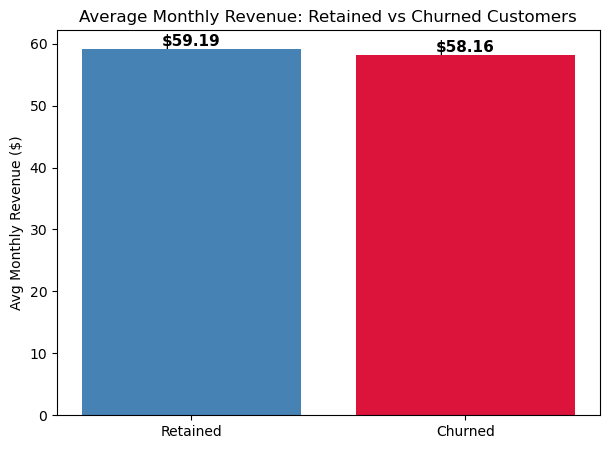

In [34]:
# average revenue lost per customer: Churned vs Retained 

avg_rev_comparison = df.groupby('churn')['monthly_revenue'].mean()

plt.figure(figsize=(7, 5))
bars = plt.bar(['Retained', 'Churned'], avg_rev_comparison.values, color=['steelblue', 'crimson'])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'${bar.get_height():.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Average Monthly Revenue: Retained vs Churned Customers')
plt.ylabel('Avg Monthly Revenue ($)')
plt.show()

Bar chart comparing average monthly revenue for retained vs churned customers.
This tests whether churners tend to be higher or lower-value customers on average, it informs whether retention efforts should be revenue-weighted.

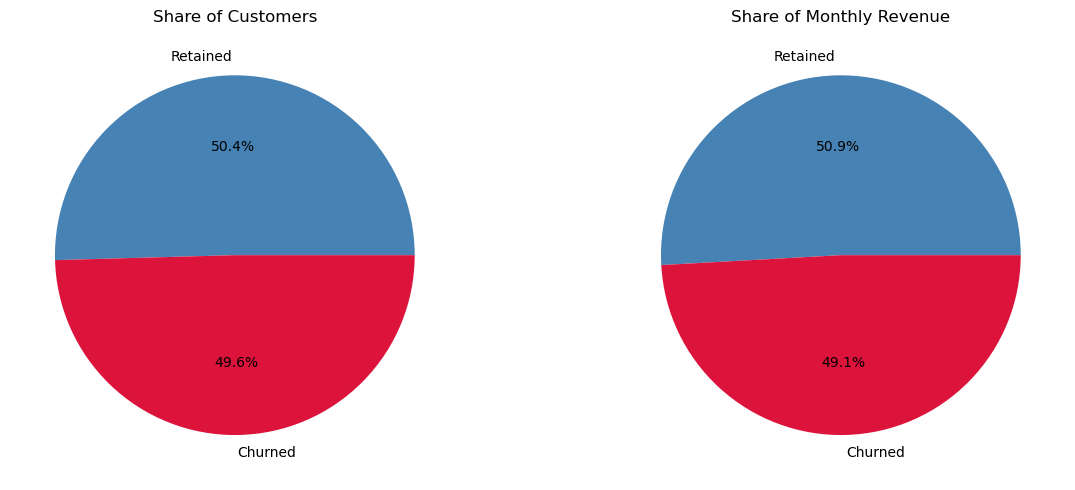

In [35]:
# revenue distribution 
revenue_by_churn = df.groupby('churn')['monthly_revenue'].sum()
customer_count_by_churn = df.groupby('churn').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(customer_count_by_churn, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=['steelblue', 'crimson'])
axes[0].set_title('Share of Customers')

axes[1].pie(revenue_by_churn, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=['steelblue', 'crimson'])
axes[1].set_title('Share of Monthly Revenue')

plt.tight_layout()
plt.show()

Side-by-side pie charts comparing churners' share of customers vs their share of monthly revenue. If the revenue-share pie is noticeably larger than the customer-share pie, it means churn is concentrated among higher-spending customers, which raises the business stakes of the problem beyond a simple headcount.


Total lifetime revenue represented by churned customers: $51,015,606
Avg lifetime revenue — churned: $1,029 vs retained: $1,034


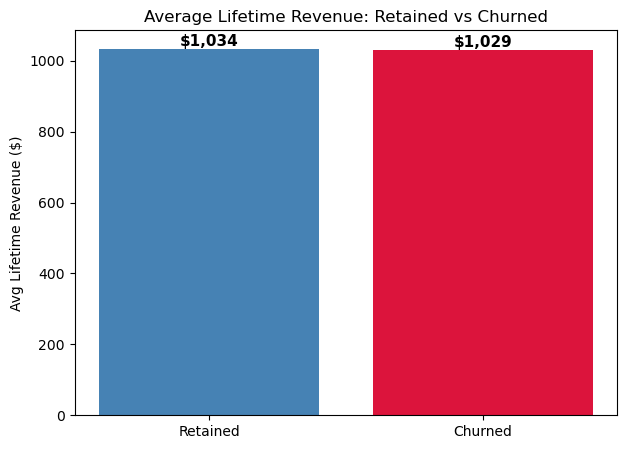

In [36]:
# lifetime value lost
ltv_lost = churned['total_lifetime_revenue'].sum()
avg_ltv_churned = churned['total_lifetime_revenue'].mean()
avg_ltv_retained = retained['total_lifetime_revenue'].mean()

print(f"\nTotal lifetime revenue represented by churned customers: ${ltv_lost:,.0f}")
print(f"Avg lifetime revenue — churned: ${avg_ltv_churned:,.0f} vs retained: ${avg_ltv_retained:,.0f}")

plt.figure(figsize=(7, 5))
bars = plt.bar(['Retained', 'Churned'], [avg_ltv_retained, avg_ltv_churned], color=['steelblue', 'crimson'])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Average Lifetime Revenue: Retained vs Churned')
plt.ylabel('Avg Lifetime Revenue ($)')
plt.show()


Revenue-at-risk by customer value tier:
  revenue_tier  churn_rate  customers  monthly_revenue_at_risk
0          Low    0.526440      25000             3.179709e+05
1      Mid-Low    0.479884      25179             4.771775e+05
2     Mid-High    0.489909      24823             6.941887e+05
3         High    0.486319      24998             1.393266e+06


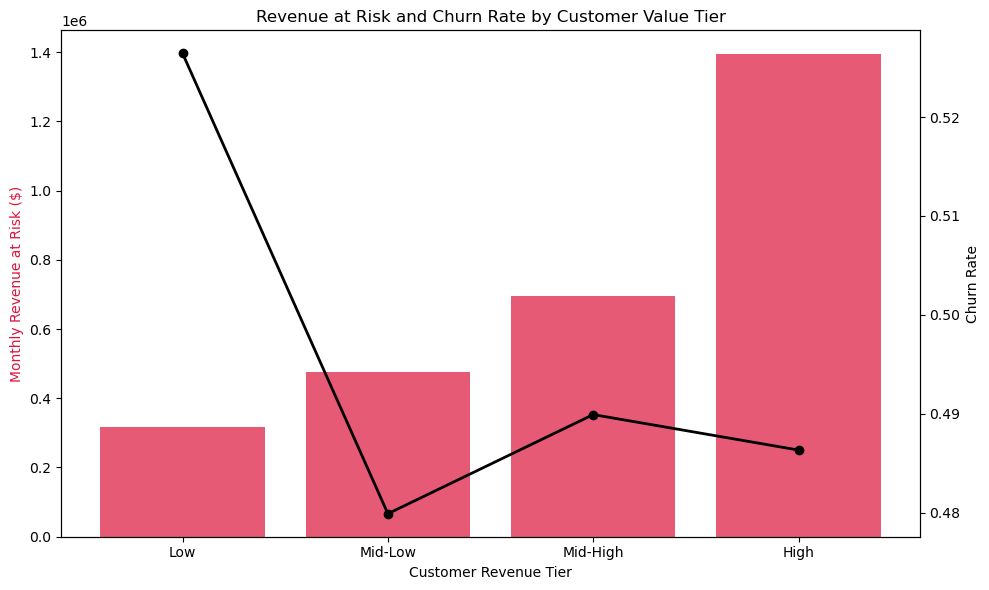

In [37]:
# Revenue-at-risk segmented by customer value tier
df['revenue_tier'] = pd.qcut(df['monthly_revenue'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

tier_churn = df.groupby('revenue_tier').agg(
    churn_rate=('churn', 'mean'),
    customers=('churn', 'size'),
    monthly_revenue_at_risk=('monthly_revenue', lambda x: x[df.loc[x.index, 'churn'] == 1].sum())
).reset_index()

print("\nRevenue-at-risk by customer value tier:")
print(tier_churn)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(tier_churn['revenue_tier'], tier_churn['monthly_revenue_at_risk'], color='crimson', alpha=0.7)
ax1.set_ylabel('Monthly Revenue at Risk ($)', color='crimson')
ax1.set_xlabel('Customer Revenue Tier')

ax2.plot(tier_churn['revenue_tier'], tier_churn['churn_rate'], color='black', marker='o', linewidth=2)
ax2.set_ylabel('Churn Rate', color='black')

plt.title('Revenue at Risk and Churn Rate by Customer Value Tier')
plt.tight_layout()
plt.show()


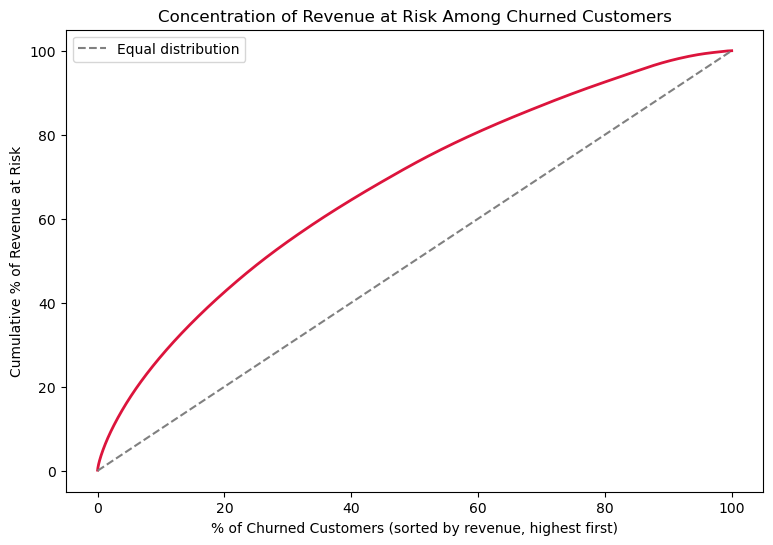

In [38]:
# Cumulative revenue-at-risk curve (Pareto-style)
churned_sorted = churned.sort_values('monthly_revenue', ascending=False).reset_index(drop=True)
churned_sorted['cum_revenue_pct'] = churned_sorted['monthly_revenue'].cumsum() / churned_sorted['monthly_revenue'].sum() * 100
churned_sorted['cum_customer_pct'] = (churned_sorted.index + 1) / len(churned_sorted) * 100

plt.figure(figsize=(9, 6))
plt.plot(churned_sorted['cum_customer_pct'], churned_sorted['cum_revenue_pct'], color='crimson', linewidth=2)
plt.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Equal distribution')
plt.xlabel('% of Churned Customers (sorted by revenue, highest first)')
plt.ylabel('Cumulative % of Revenue at Risk')
plt.title('Concentration of Revenue at Risk Among Churned Customers')
plt.legend()
plt.show()

In [39]:
# Monthly revenue lost + churn rate by equipment age bucket
df['equipment_age_bucket'] = pd.cut(df['equipment_age_years'], bins=[0, 1, 2, 3, 5, 100],
                                      labels=['<1yr', '1-2yr', '2-3yr', '3-5yr', '5yr+'])

eqp_summary = df.groupby('equipment_age_bucket').agg(
    churn_rate=('churn', 'mean'),
    revenue_at_risk=('monthly_revenue', lambda x: x[df.loc[x.index, 'churn'] == 1].sum())
).reset_index()

print("\nRevenue at risk by equipment age:")
print(eqp_summary)


Revenue at risk by equipment age:
  equipment_age_bucket  churn_rate  revenue_at_risk
0                 <1yr    0.452519     1.633011e+06
1                1-2yr    0.538386     9.707021e+05
2                2-3yr    0.575286     2.396785e+05
3                3-5yr    0.600773     3.352973e+04
4                 5yr+         NaN     0.000000e+00


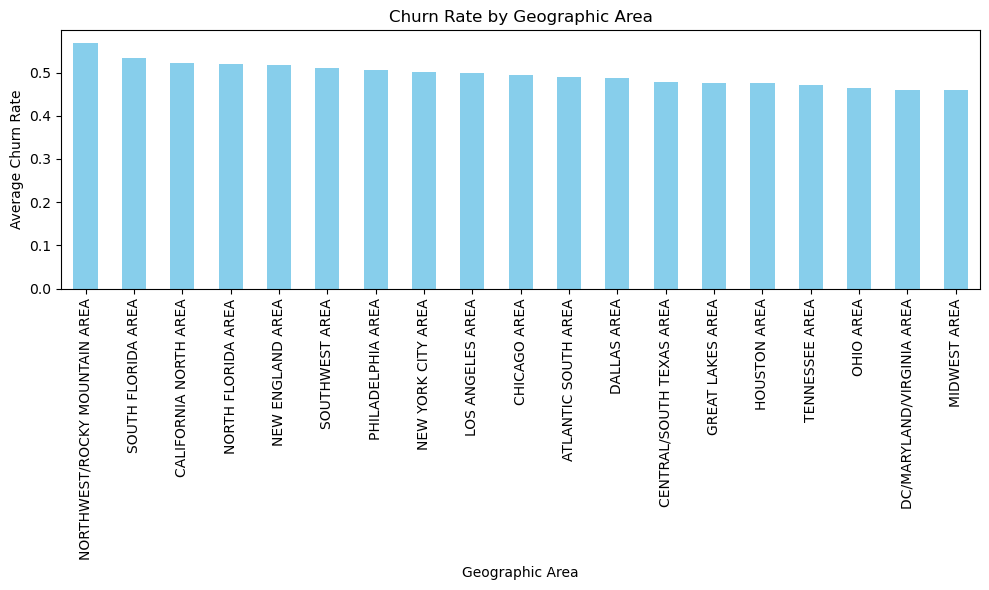

In [40]:
# Churn Rate by Geographic Area
area_churn = df.groupby('geographic_area')['churn'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
area_churn.plot(kind='bar', color='skyblue')
plt.title('Churn Rate by Geographic Area')
plt.ylabel('Average Churn Rate')
plt.xlabel('Geographic Area')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [41]:
new_ratio_cols = [
    'cost_per_minute', 'recurring_charge_per_minute', 'overage_mou_pct', 'overage_rev_pct',
    'voice_call_failure_rate', 'data_call_failure_rate', 'call_completion_rate', 'avg_vce_call_duration',
    'cust_care_per_month', 'cust_care_mins_per_call', 'peak_vce_pct', 'mou_per_subscriber',
    'active_subscriber_ratio', 'mou_3m_vs_lifetime_ratio', 'mou_3m_vs_6m_ratio', 'rev_3m_vs_lifetime_ratio',
    'lifetime_rev_per_month', 'revenue_adjustment_rate', 'handsets_per_model', 'handset_price_to_revenue_ratio',
    'equipment_age_years'
]

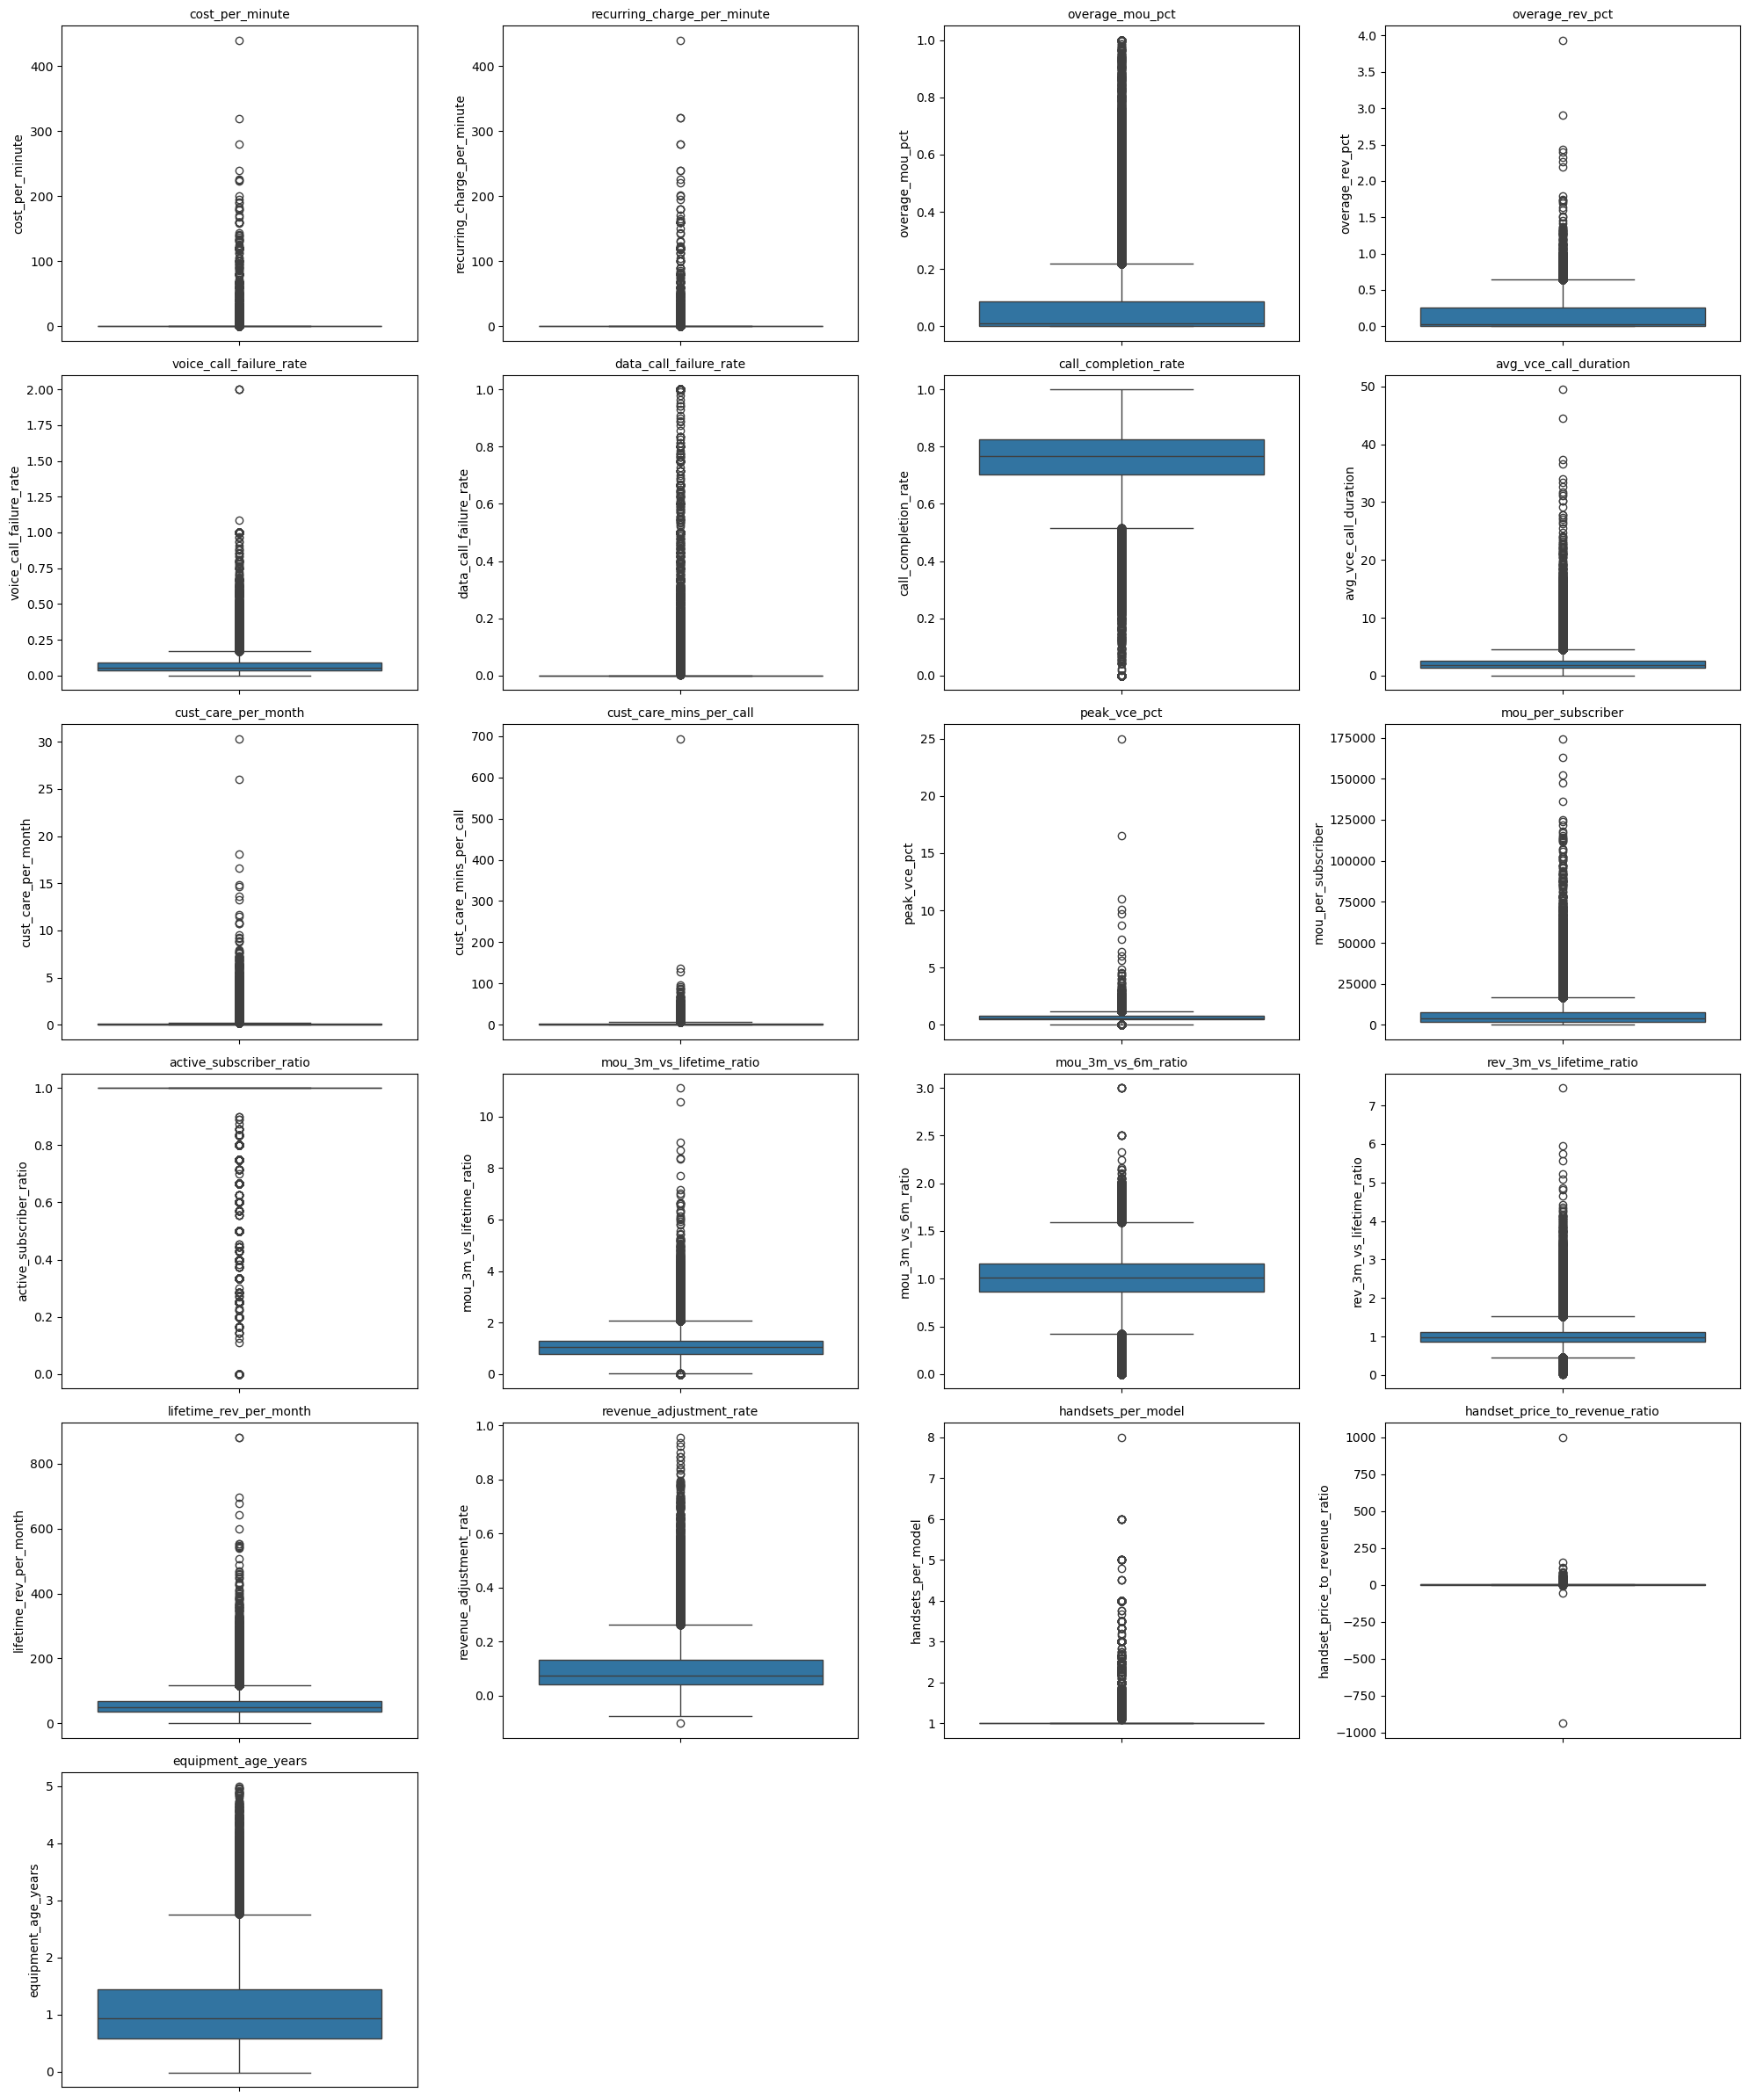

In [42]:
n_cols = 4
n_rows = int(np.ceil(len(new_ratio_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(new_ratio_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

for j in range(len(new_ratio_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

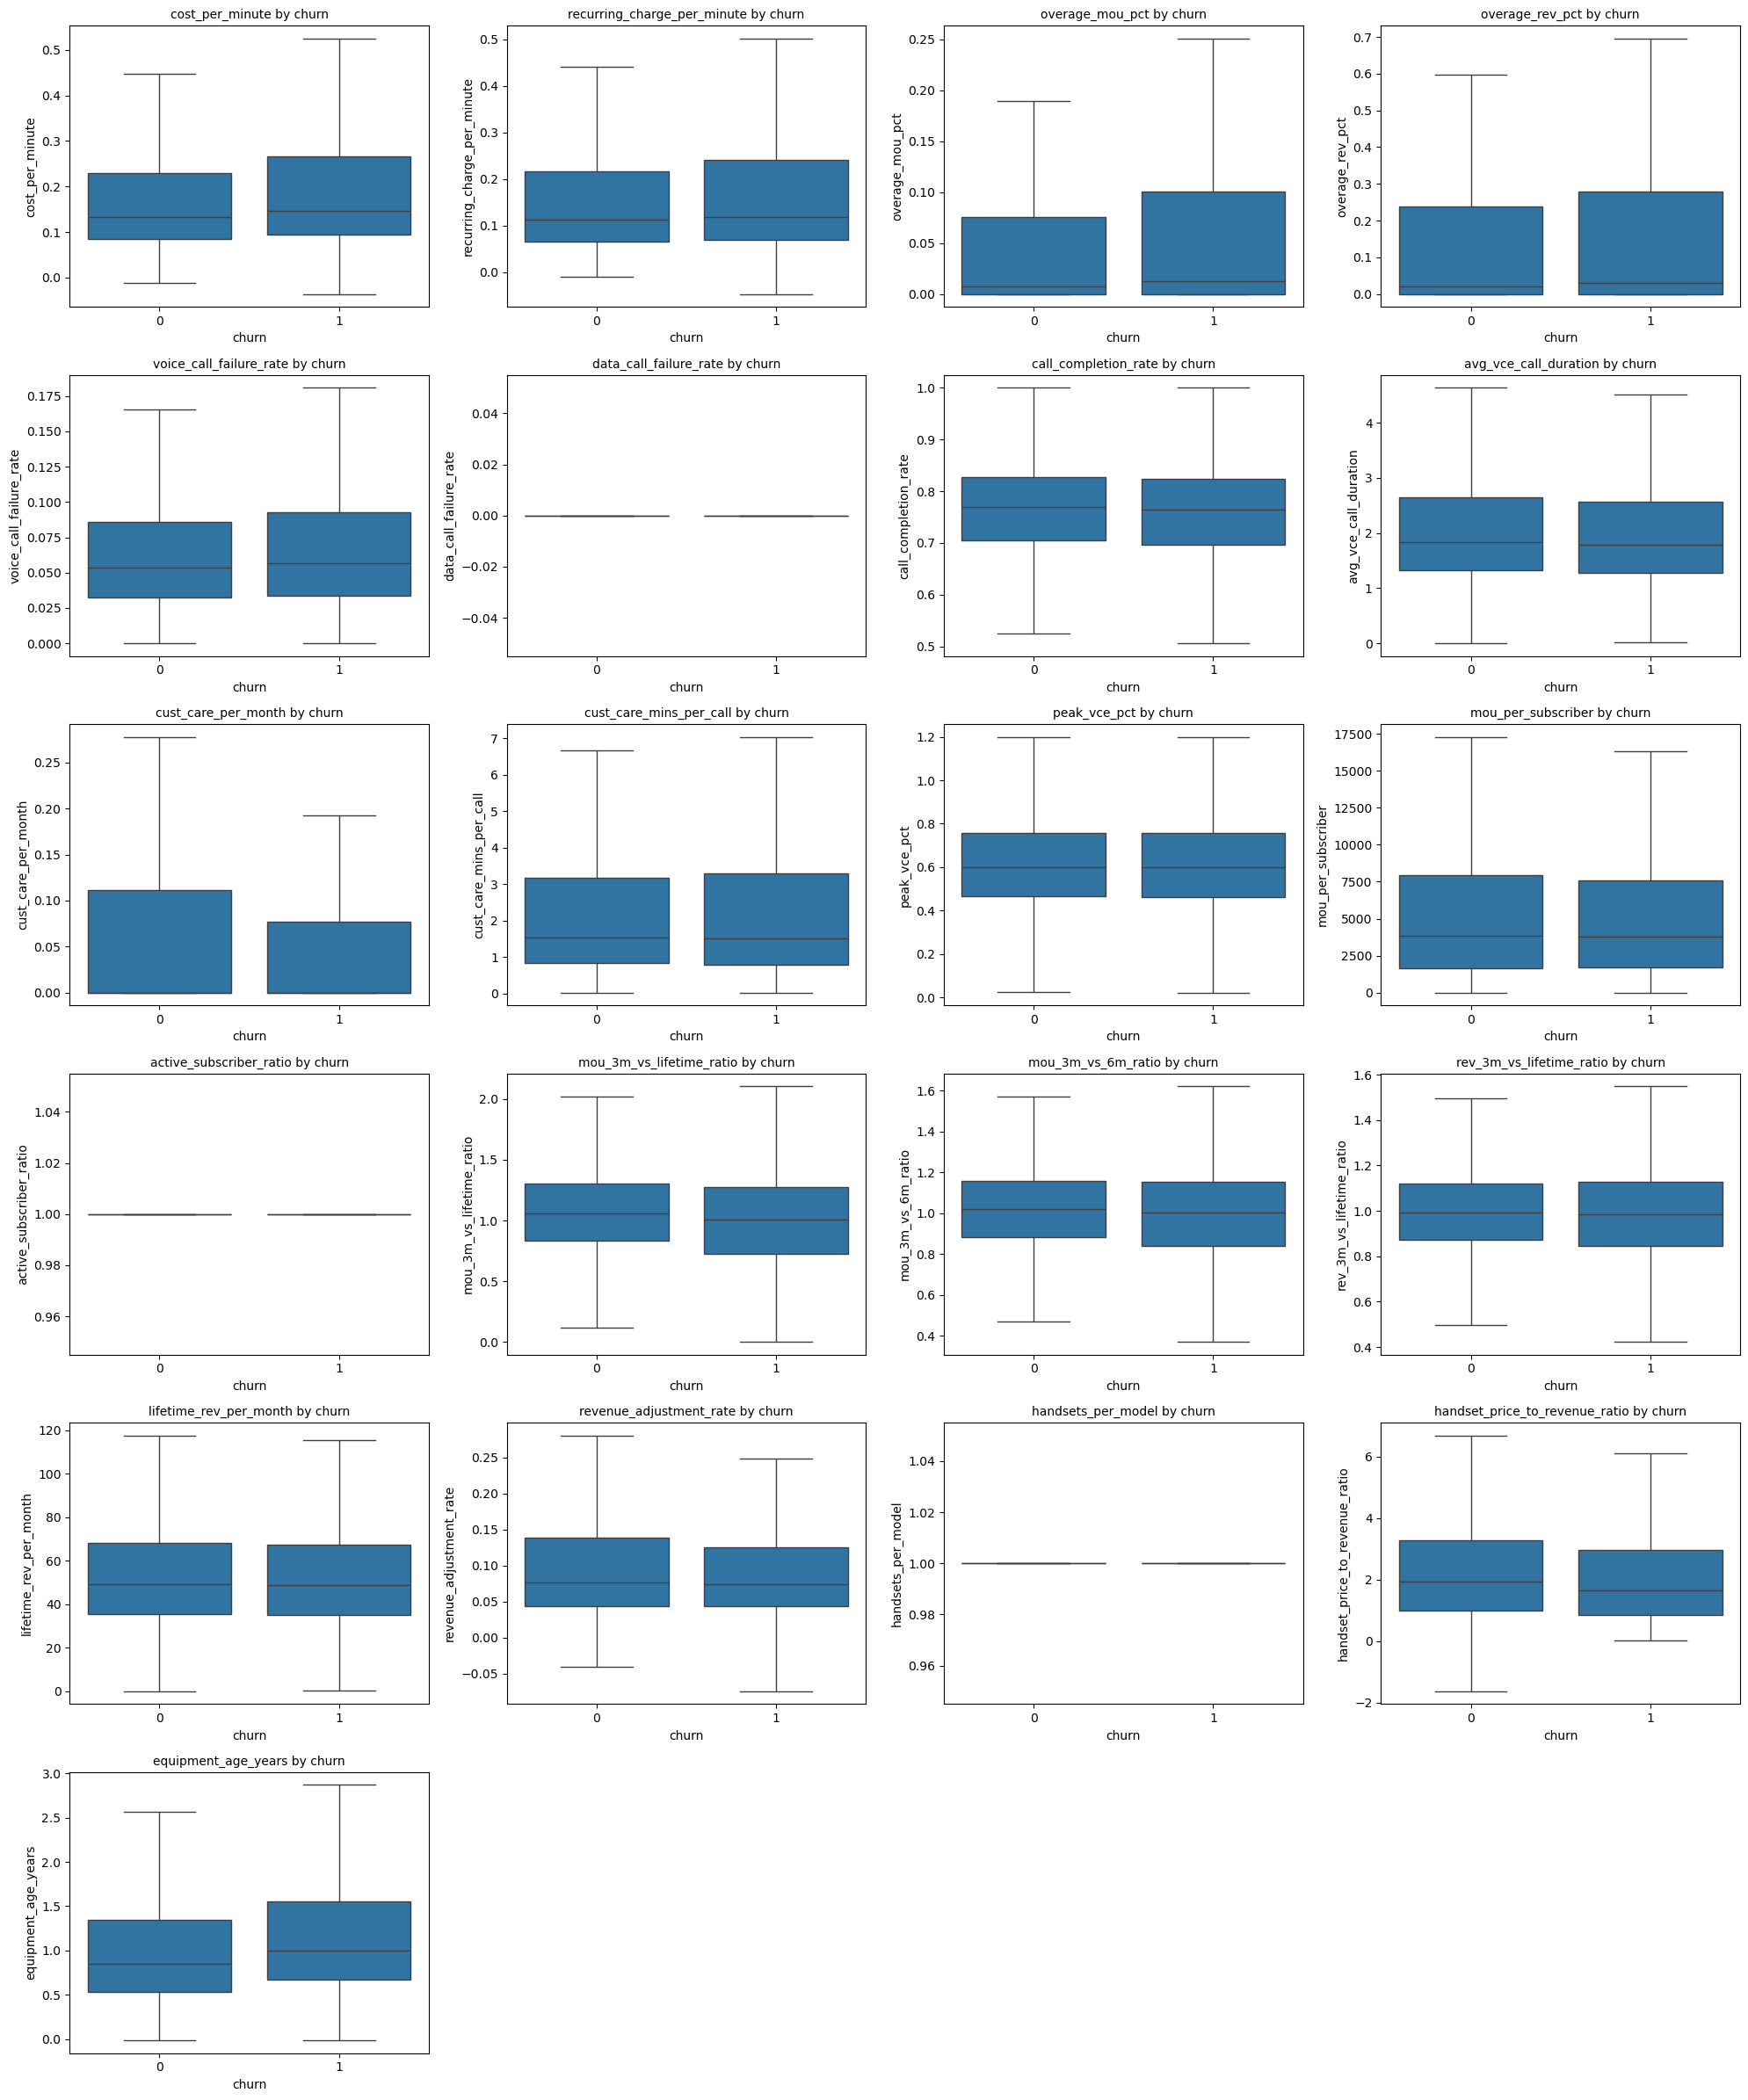

In [43]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(new_ratio_cols):
    sns.boxplot(x='churn', y=col, data=df, ax=axes[i], showfliers=False)
    axes[i].set_title(f'{col} by churn', fontsize=10)

for j in range(len(new_ratio_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

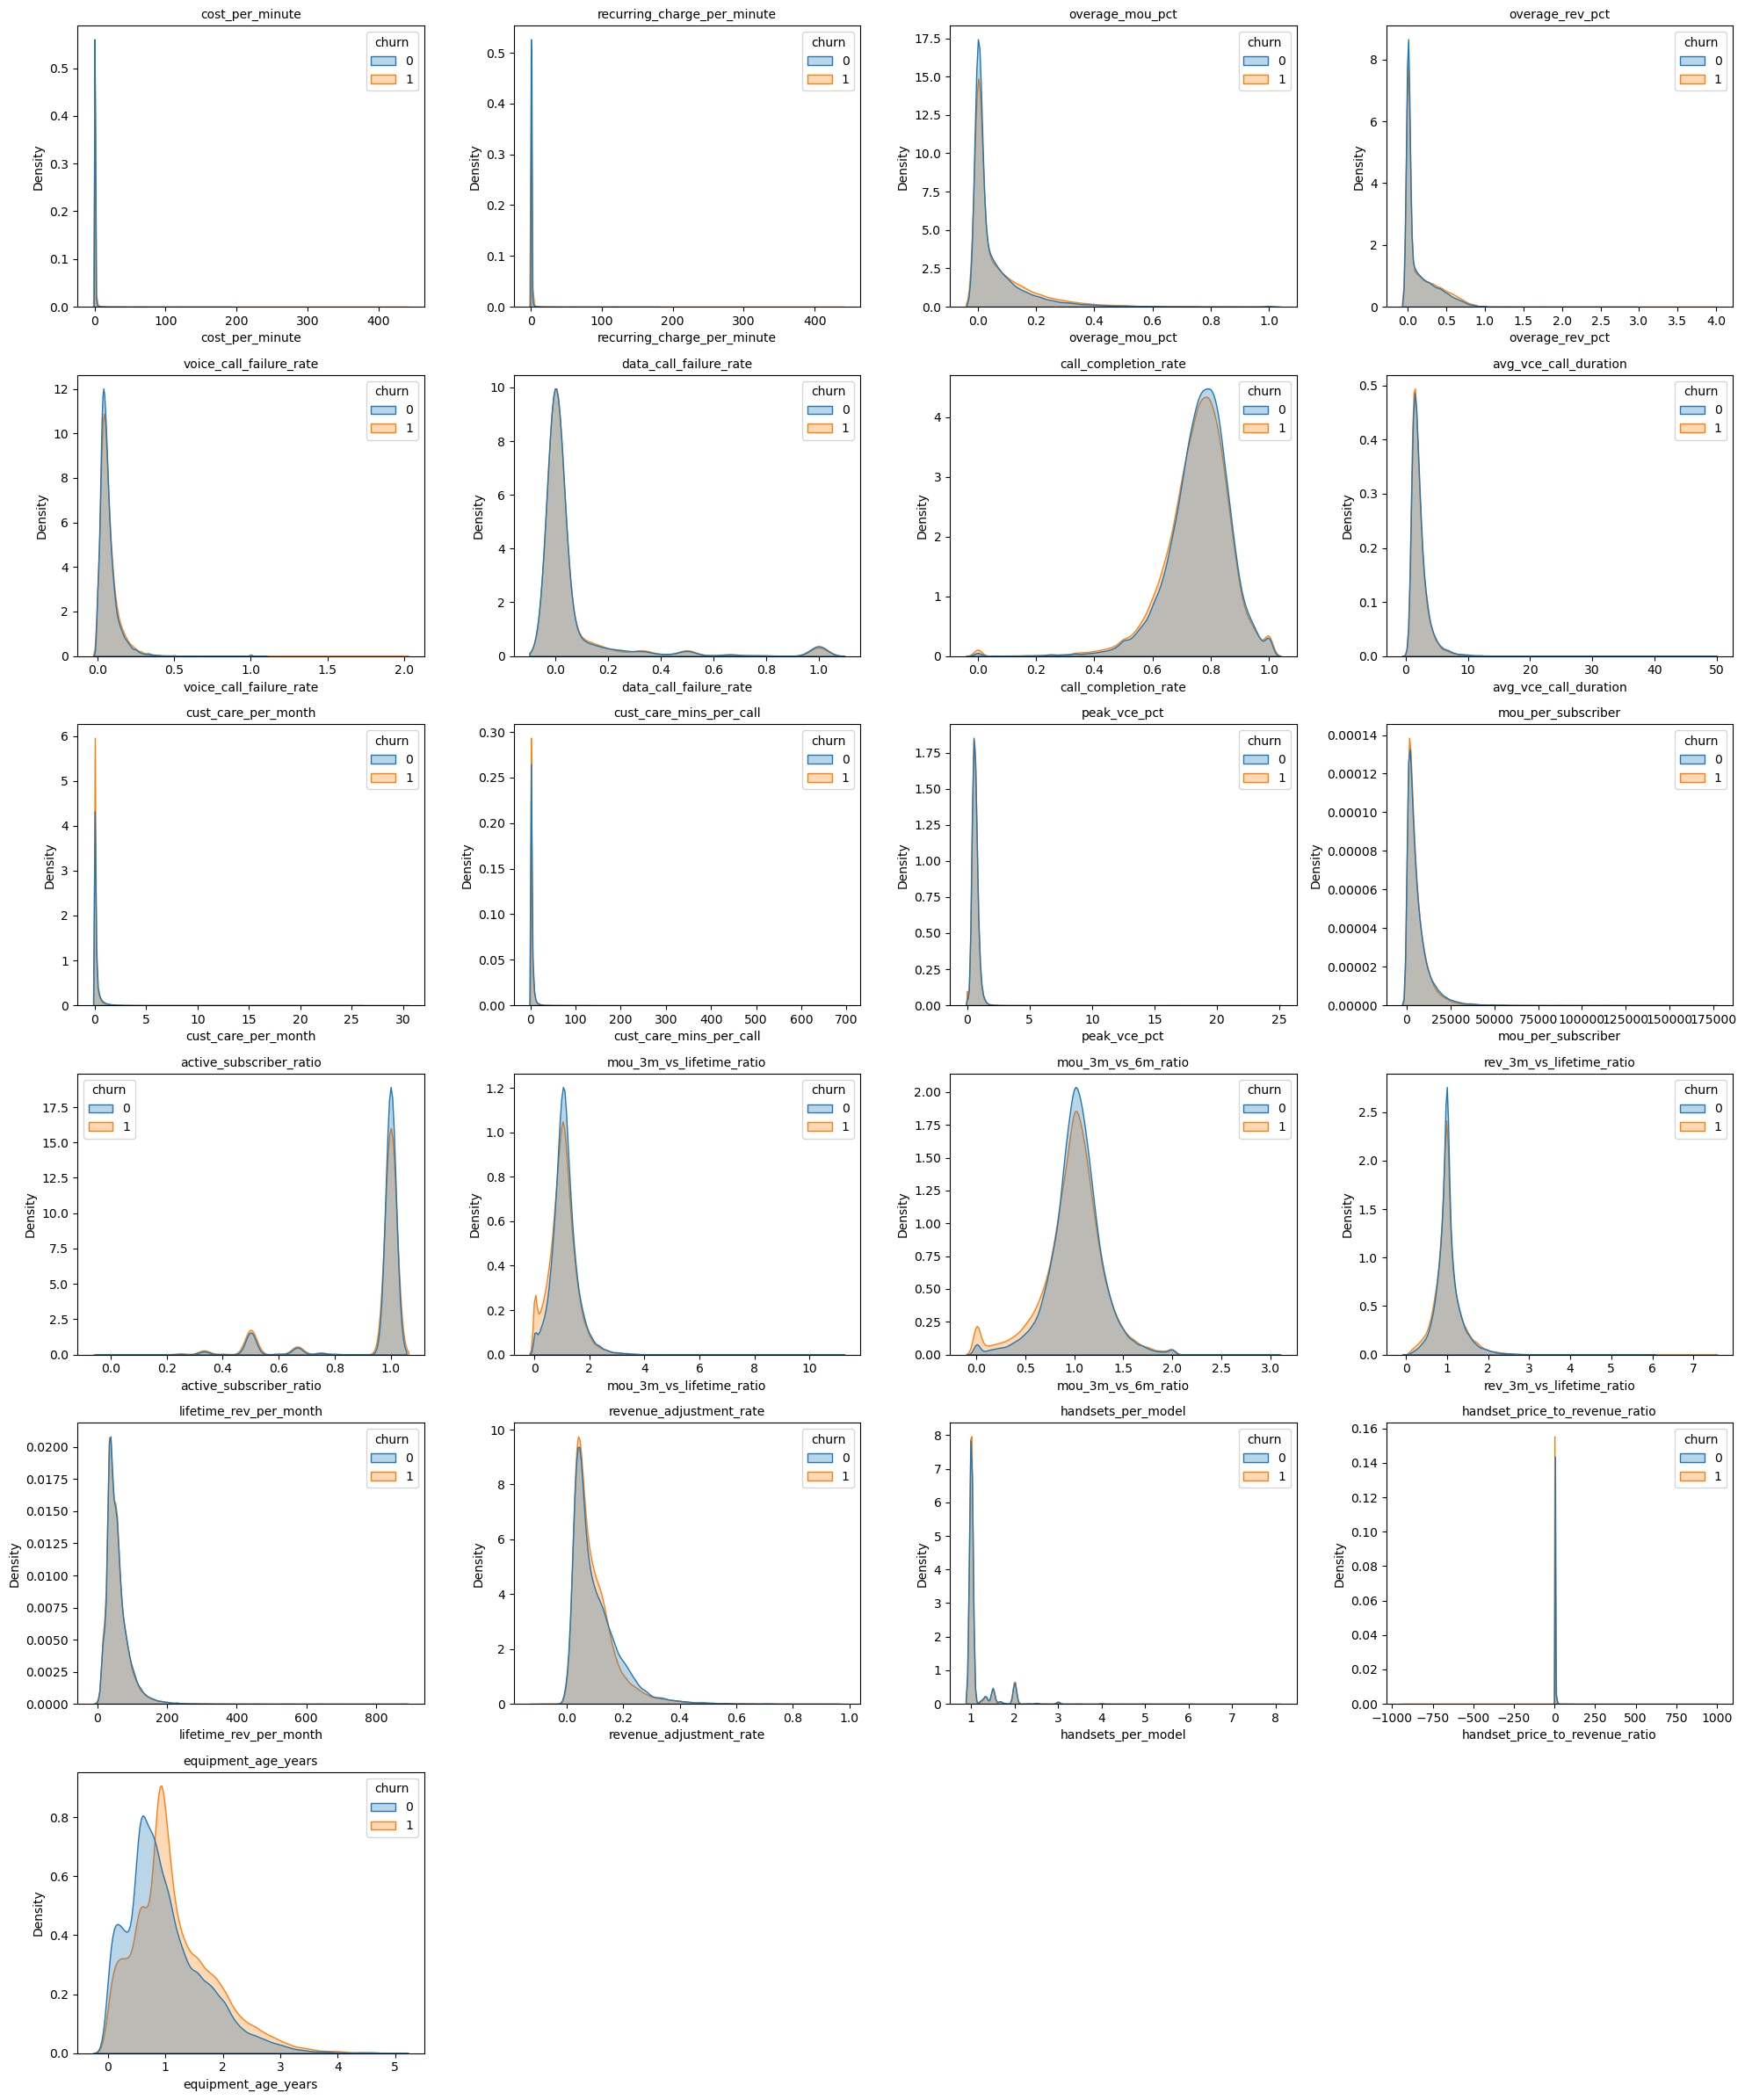

In [44]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(new_ratio_cols):
    sns.kdeplot(data=df, x=col, hue='churn', common_norm=False, ax=axes[i], fill=True, alpha=0.3)
    axes[i].set_title(col, fontsize=10)

for j in range(len(new_ratio_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

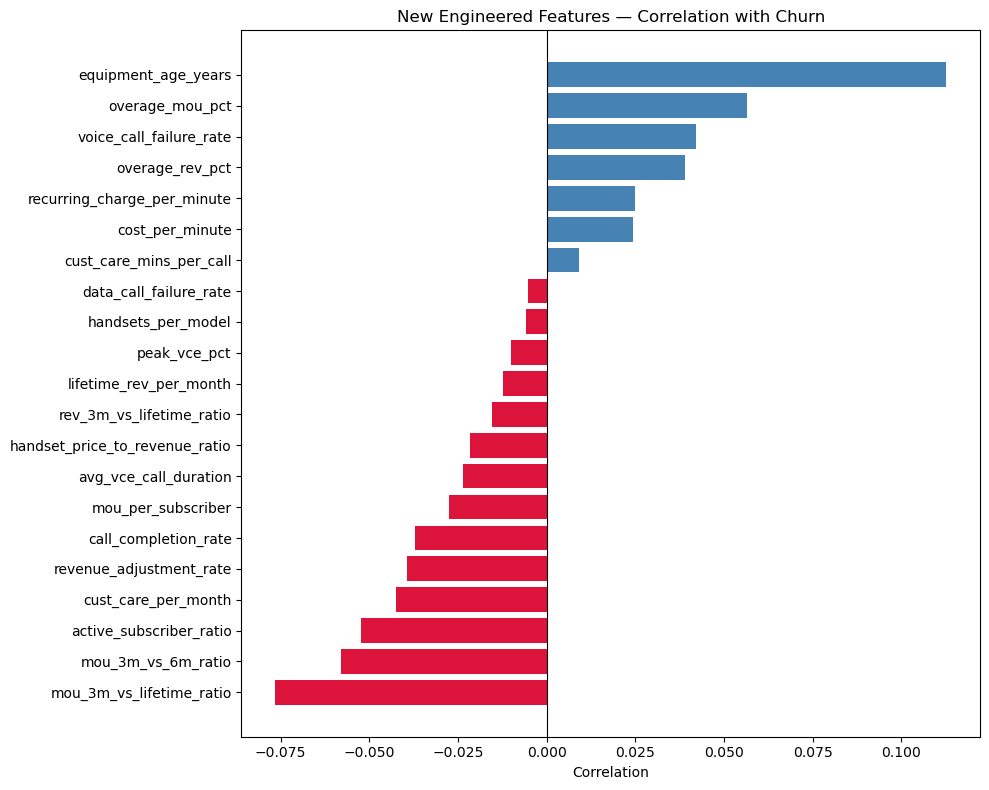

In [45]:
new_feature_corr = df[new_ratio_cols + ['churn']].corr()['churn'].drop('churn').sort_values()

plt.figure(figsize=(10, 8))
colors = ['crimson' if x < 0 else 'steelblue' for x in new_feature_corr.values]
plt.barh(new_feature_corr.index, new_feature_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('New Engineered Features — Correlation with Churn')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

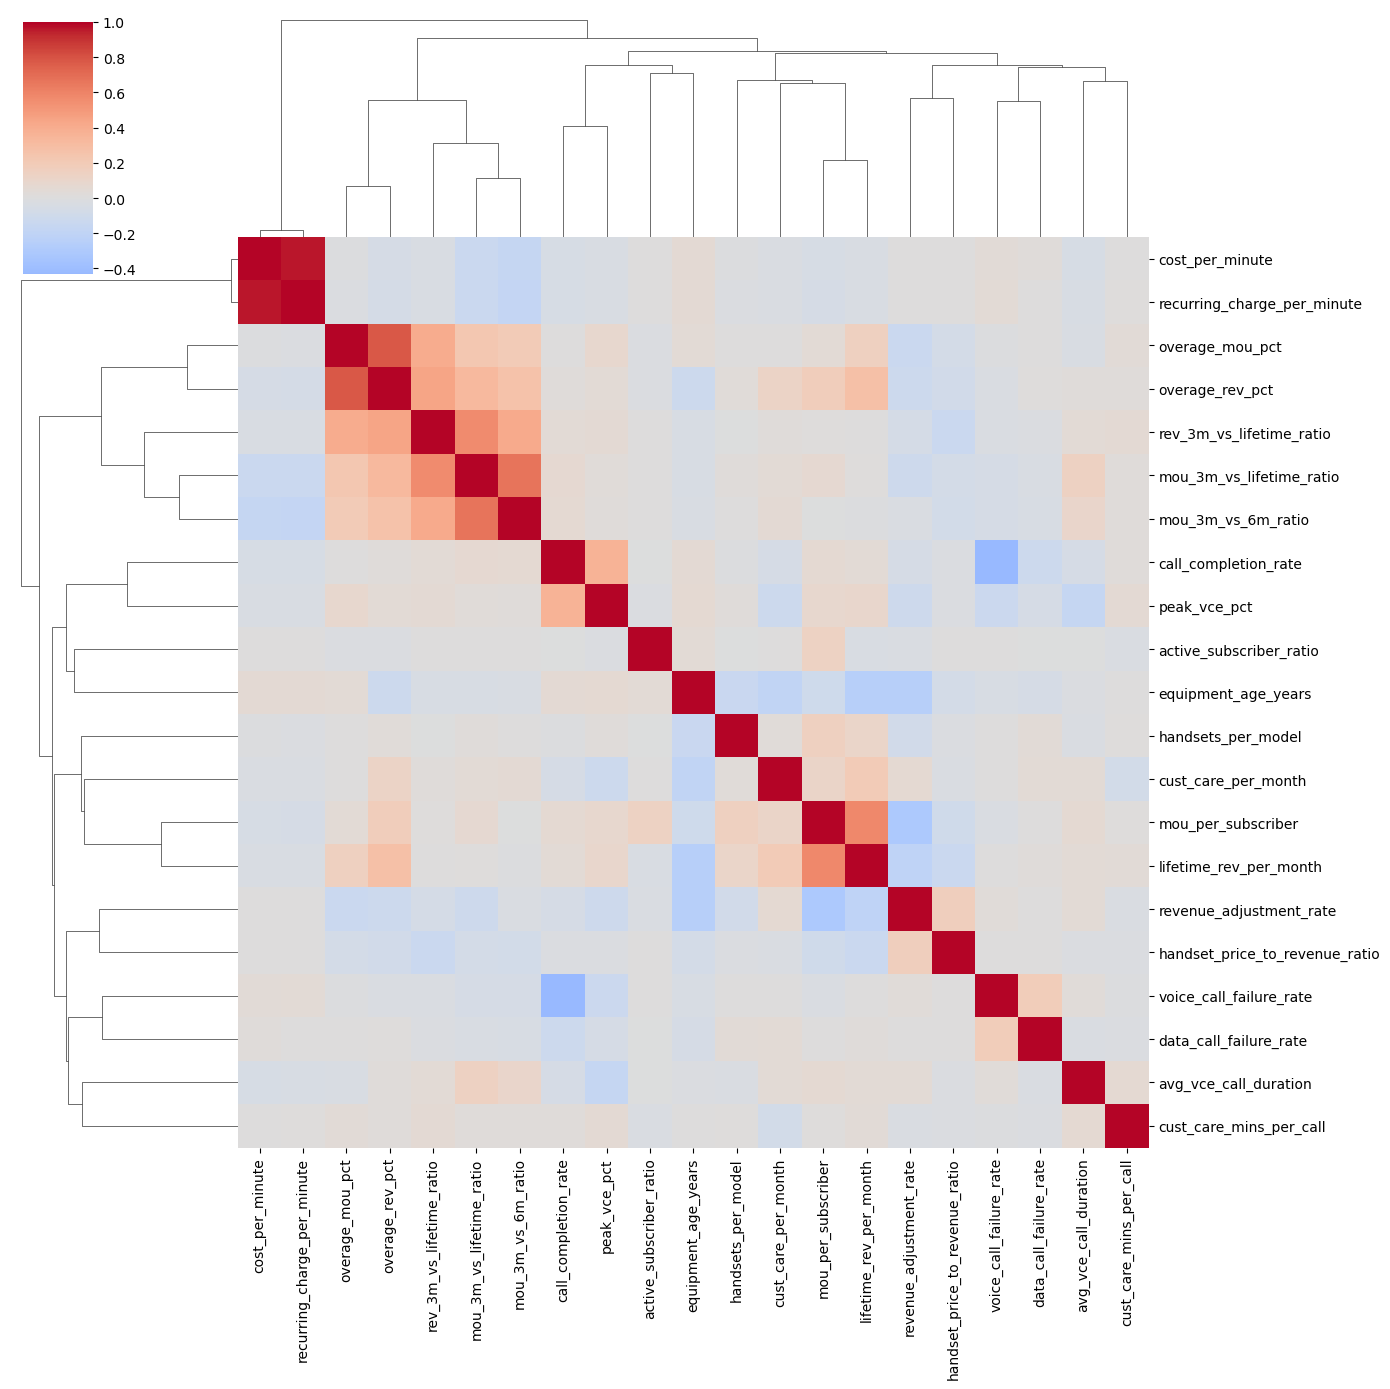

In [46]:
new_feat_corr_matrix = df[new_ratio_cols].corr()

sns.clustermap(
    new_feat_corr_matrix,
    cmap='coolwarm', center=0, figsize=(14, 14),
    xticklabels=True, yticklabels=True
)
plt.show()

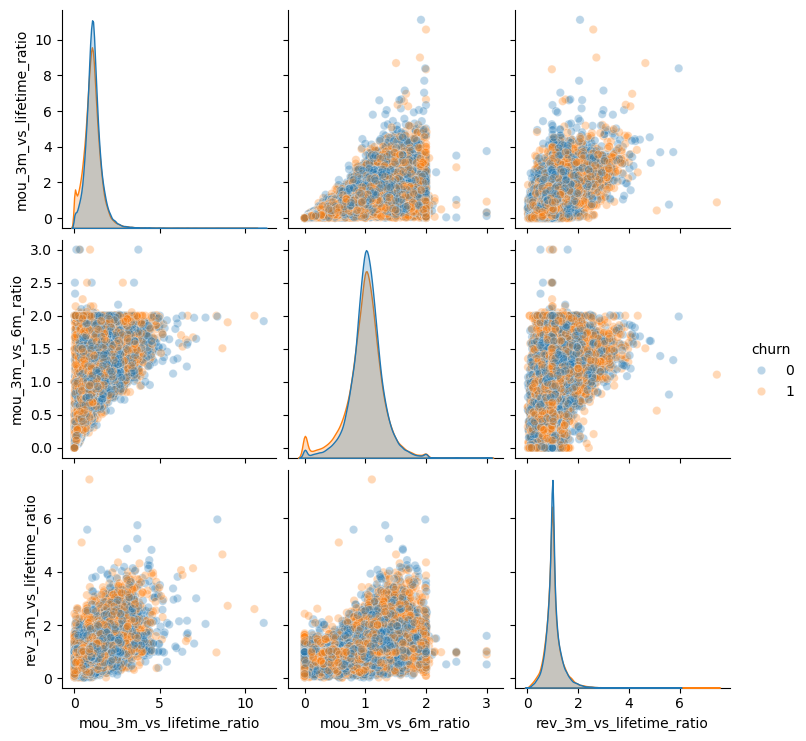

In [47]:
trend_cols = ['mou_3m_vs_lifetime_ratio', 'mou_3m_vs_6m_ratio', 'rev_3m_vs_lifetime_ratio', 'churn']
sns.pairplot(df[trend_cols].dropna(), hue='churn', diag_kind='kde', plot_kws={'alpha': 0.3})
plt.show()

### Handling missing values 

In [48]:
df.isnull().sum()

monthly_revenue                     0
monthly_minutes                     0
monthly_recurring_charge            0
directory_assist_calls              0
overage_minutes                     0
                                 ... 
equipment_age_years                 1
handsets_per_model                  1
handset_price_to_revenue_ratio    859
revenue_tier                        0
equipment_age_bucket              167
Length: 123, dtype: int64

In [49]:

# ---- Layer 1: demo block ----
demo_block = ['truck_indicator', 'rv_indicator', 'marital_status', 'foreign_travel_flag', 'ethnicity_code',
              'child_0_2_flag', 'child_3_5_flag', 'child_6_10_flag', 'child_11_15_flag', 'child_16_17_flag',
              'credit_card_indicator']

df['demo_match_flag'] = df[demo_block].notnull().all(axis=1).astype(int)

# ---- Layer 2a: infobase match flag ----
df['infobase_match_flag'] = df['infobase_match'].notnull().astype(int)

# ---- Layer 2b: property/dwelling cluster — soft count of how many are present ----
property_cluster = ['estimated_income', 'length_of_residence', 'dwelling_type',
                     'home_owner_or_renter', 'num_adults_household', 'dwelling_size']

df['property_data_count'] = df[property_cluster].notnull().sum(axis=1)

# ---- Layer 3: standalone columns with independent missingness ----
df['hhstatin_missing_flag'] = df['household_status_indicator'].isnull().astype(int)
df['numbcars_missing_flag'] = df['num_vehicles'].isnull().astype(int)

# ---- Verify all flags created correctly ----
flag_cols = ['demo_match_flag', 'infobase_match_flag', 'property_data_count',
             'hhstatin_missing_flag', 'numbcars_missing_flag']
print(df[flag_cols].describe())

       demo_match_flag  infobase_match_flag  property_data_count  \
count    100000.000000        100000.000000        100000.000000   
mean          0.982680             0.779210             4.174320   
std           0.130461             0.414781             2.493318   
min           0.000000             0.000000             0.000000   
25%           1.000000             1.000000             2.000000   
50%           1.000000             1.000000             6.000000   
75%           1.000000             1.000000             6.000000   
max           1.000000             1.000000             6.000000   

       hhstatin_missing_flag  numbcars_missing_flag  
count          100000.000000          100000.000000  
mean                0.379230               0.493660  
std                 0.485198               0.499962  
min                 0.000000               0.000000  
25%                 0.000000               0.000000  
50%                 0.000000               0.000000  
75%      

In [50]:
overall_churn = df['churn'].mean()
print(f"Overall churn rate: {overall_churn:.4f}\n")

# Binary flags
for flag in ['demo_match_flag', 'infobase_match_flag', 'hhstatin_missing_flag', 'numbcars_missing_flag']:
    churn_by_flag = df.groupby(flag)['churn'].mean()
    print(f"{flag}:\n{churn_by_flag}\n")

# property_data_count is 0-6, check churn rate across each count level
print("property_data_count vs churn:")
print(df.groupby('property_data_count')['churn'].mean())

Overall churn rate: 0.4956

demo_match_flag:
demo_match_flag
0    0.478637
1    0.495919
Name: churn, dtype: float64

infobase_match_flag:
infobase_match_flag
0    0.519815
1    0.488764
Name: churn, dtype: float64

hhstatin_missing_flag:
hhstatin_missing_flag
0    0.486911
1    0.509875
Name: churn, dtype: float64

numbcars_missing_flag:
numbcars_missing_flag
0    0.489078
1    0.502330
Name: churn, dtype: float64

property_data_count vs churn:
property_data_count
0    0.517130
1    0.479980
2    0.507951
3    0.504854
4    0.511988
5    0.490476
6    0.485766
Name: churn, dtype: float64


In [51]:
from scipy.stats import chi2_contingency

for flag in ['demo_match_flag', 'infobase_match_flag', 'hhstatin_missing_flag', 'numbcars_missing_flag']:
    contingency = pd.crosstab(df[flag], df['churn'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{flag}: chi2={chi2:.2f}, p-value={p:.4f}")

demo_match_flag: chi2=1.96, p-value=0.1610
infobase_match_flag: chi2=66.23, p-value=0.0000
hhstatin_missing_flag: chi2=49.57, p-value=0.0000
numbcars_missing_flag: chi2=17.50, p-value=0.0000


In [52]:
# current status 
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
print("Columns with missing values before imputation:")
print(missing_before)

Columns with missing values before imputation:
data_call_failure_rate            85020
cust_care_mins_per_call           55692
num_vehicles                      49366
dwelling_size                     38308
household_status_indicator        37923
home_owner_or_renter              33706
dwelling_type                     31909
length_of_residence               30190
estimated_income                  25436
num_adults_household              23019
infobase_match                    22079
handset_web_capable               10189
avg_vce_call_duration              8413
voice_call_failure_rate            8169
peak_vce_pct                       8169
call_completion_rate               8160
social_group_code                  7388
mou_3m_vs_6m_ratio                 3557
avg_mou_last_6_months              2839
avg_calls_last_6_months            2839
avg_rev_last_6_months              2839
child_3_5_flag                     1732
rv_indicator                       1732
truck_indicator                  

In [53]:
#numeric columns fill with median based on outlier report
numeric_cols_with_na = df.select_dtypes(include=np.number).columns[
    df.select_dtypes(include=np.number).isnull().any()
]
print(f"\nNumeric columns to impute: {list(numeric_cols_with_na)}")

for col in numeric_cols_with_na:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled with median = {median_val:.2f}")


Numeric columns to impute: ['avg_mou_last_6_months', 'avg_calls_last_6_months', 'avg_rev_last_6_months', 'handset_price', 'handsets_issued', 'models_issued', 'truck_indicator', 'rv_indicator', 'length_of_residence', 'num_adults_household', 'estimated_income', 'num_vehicles', 'foreign_travel_flag', 'equipment_age_days', 'cost_per_minute', 'recurring_charge_per_minute', 'overage_mou_pct', 'overage_rev_pct', 'voice_call_failure_rate', 'data_call_failure_rate', 'call_completion_rate', 'avg_vce_call_duration', 'cust_care_mins_per_call', 'peak_vce_pct', 'mou_3m_vs_lifetime_ratio', 'mou_3m_vs_6m_ratio', 'equipment_age_years', 'handsets_per_model', 'handset_price_to_revenue_ratio']
  avg_mou_last_6_months: filled with median = 363.00
  avg_calls_last_6_months: filled with median = 127.00
  avg_rev_last_6_months: filled with median = 50.00
  handset_price: filled with median = 99.99
  handsets_issued: filled with median = 1.00
  models_issued: filled with median = 1.00
  truck_indicator: fille

In [54]:
# categorical columns fill with unknown 
cat_cols_with_na = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()
]
print(f"\nCategorical columns to impute: {list(cat_cols_with_na)}")

for col in cat_cols_with_na:
    df[col] = df[col].fillna('Unknown')


Categorical columns to impute: ['social_group_code', 'geographic_area', 'dualband_handset', 'handset_refurb_or_new', 'handset_web_capable', 'home_owner_or_renter', 'dwelling_type', 'marital_status', 'infobase_match', 'household_status_indicator', 'dwelling_size', 'ethnicity_code', 'child_0_2_flag', 'child_3_5_flag', 'child_6_10_flag', 'child_11_15_flag', 'child_16_17_flag', 'credit_card_indicator']


In [55]:
remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(remaining)
print("\nDtypes of remaining missing columns:")
print(df[remaining.index].dtypes)

equipment_age_bucket    167
dtype: int64

Dtypes of remaining missing columns:
equipment_age_bucket    category
dtype: object


In [56]:

missing_cols = df.columns[df.isnull().any()]
print("All columns still missing anything:", list(missing_cols))

for col in missing_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: numeric -> filled with median {median_val}")
    elif pd.api.types.is_categorical_dtype(df[col]):
        # category dtype needs the fill value added as a category first
        if 'Unknown' not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories('Unknown')
        df[col] = df[col].fillna('Unknown')
        print(f"{col}: category -> filled with 'Unknown'")
    elif pd.api.types.is_bool_dtype(df[col]):
        df[col] = df[col].fillna(False)
        print(f"{col}: boolean -> filled with False")
    else:
        # object / string / anything else
        df[col] = df[col].fillna('Unknown')
        print(f"{col}: object/other -> filled with 'Unknown'")

# Re-check
remaining_missing = df.isnull().sum().sum()
print(f"\nTotal remaining missing values: {remaining_missing}")
assert remaining_missing == 0, "Missing values still present — check dtypes/edge cases"
print("Final shape:", df.shape)

All columns still missing anything: ['equipment_age_bucket']
equipment_age_bucket: category -> filled with 'Unknown'

Total remaining missing values: 0
Final shape: (100000, 128)


In [57]:
# Confirm the flags still make sense post-imputation

flag_cols = ['demo_match_flag', 'infobase_match_flag', 'property_data_count',
             'hhstatin_missing_flag', 'numbcars_missing_flag']
print(df[flag_cols].isnull().sum())

# Spot-check a few imputed columns for sanity

print(df[['estimated_income', 'length_of_residence', 'num_vehicles']].describe())

# Confirm categorical fills worked and didn't collide with a real category
for col in cat_cols_with_na:
    print(col, ":", df[col].value_counts().get('Unknown', 0), "filled as Unknown")

demo_match_flag          0
infobase_match_flag      0
property_data_count      0
hhstatin_missing_flag    0
numbcars_missing_flag    0
dtype: int64
       estimated_income  length_of_residence   num_vehicles
count     100000.000000        100000.000000  100000.000000
mean           5.838280             5.821830       1.287380
std            1.886643             3.993162       0.527821
min            1.000000             0.000000       1.000000
25%            5.000000             3.000000       1.000000
50%            6.000000             5.000000       1.000000
75%            7.000000             7.000000       2.000000
max            9.000000            15.000000       3.000000
social_group_code : 7388 filled as Unknown
geographic_area : 40 filled as Unknown
dualband_handset : 1 filled as Unknown
handset_refurb_or_new : 1 filled as Unknown
handset_web_capable : 10189 filled as Unknown
home_owner_or_renter : 33706 filled as Unknown
dwelling_type : 31909 filled as Unknown
marital_status

In [58]:
### handling outliers 
# Numeric columns to check — exclude ID, target, and flag columns (flags are 0/1, not meaningful for outlier checks)
exclude_cols = ['Customer_ID', 'churn', 'demo_match_flag', 'infobase_match_flag',
                 'property_data_count', 'hhstatin_missing_flag', 'numbcars_missing_flag']

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

z_outlier_summary = []

for col in numeric_cols:
    # nan_policy='omit' as a safety net, though df should have no NaNs at this point
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    n_outliers = (z_scores > 3).sum()
    pct_outliers = 100 * n_outliers / len(df)

    z_outlier_summary.append({
        'column': col,
        'n_outliers_z3': n_outliers,
        'pct_outliers_z3': pct_outliers
    })

z_outlier_df = pd.DataFrame(z_outlier_summary).sort_values('pct_outliers_z3', ascending=False)
print(z_outlier_df.to_string(index=False))


                         column  n_outliers_z3  pct_outliers_z3
                   rv_indicator           8115            8.115
            foreign_travel_flag           5697            5.697
                   num_vehicles           3690            3.690
         off_peak_voice_minutes           2307            2.307
             mou_3m_vs_6m_ratio           2205            2.205
                overage_mou_pct           2164            2.164
                handsets_issued           2160            2.160
         received_voice_minutes           2124            2.124
           off_peak_voice_calls           1994            1.994
         inbound_wireless_calls           1986            1.986
        completed_voice_minutes           1969            1.969
        active_subscriber_ratio           1957            1.957
             peak_voice_minutes           1947            1.947
       inbound_wireless_minutes           1940            1.940
          voice_overage_revenue         

In [59]:
# Check cardinality to confirm these are categorical-like
for col in ['rv_indicator', 'foreign_travel_flag', 'num_vehicles']:
    print(col, df[col].nunique(), df[col].value_counts().head())

rv_indicator 2 rv_indicator
0.0    91885
1.0     8115
Name: count, dtype: int64
foreign_travel_flag 2 foreign_travel_flag
0.0    94303
1.0     5697
Name: count, dtype: int64
num_vehicles 3 num_vehicles
1.0    74952
2.0    21358
3.0     3690
Name: count, dtype: int64


In [60]:

# Identify low-cardinality numeric columns (likely binary/categorical-coded, not truly continuous)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Customer_ID', 'churn', 'demo_match_flag', 'infobase_match_flag',
                 'property_data_count', 'hhstatin_missing_flag', 'numbcars_missing_flag']

candidate_cols = [c for c in numeric_cols if c not in exclude_cols]

cardinality = df[candidate_cols].nunique().sort_values()
print(cardinality.head(20))  # inspect the low end

# Flag anything with very few unique values as categorical-like, not continuous
low_cardinality_threshold = 10  # adjust based on what you see above
low_card_cols = cardinality[cardinality <= low_cardinality_threshold].index.tolist()
print("\nLow-cardinality columns to exclude from outlier treatment:")
print(low_card_cols)

# Final list of truly continuous columns for outlier treatment
continuous_cols = [c for c in candidate_cols if c not in low_card_cols]
print(f"\n{len(continuous_cols)} continuous columns remain for outlier treatment")

truck_indicator             2
foreign_travel_flag         2
rv_indicator                2
num_vehicles                3
num_adults_household        6
estimated_income            9
active_subscribers         12
models_issued              14
unique_subscribers         15
length_of_residence        16
handset_price              17
handsets_issued            24
active_subscriber_ratio    36
call_forward_calls         45
unanswered_data_calls      52
blocked_data_calls         54
months_in_service          56
dropped_data_calls         60
handsets_per_model         61
three_way_calls            91
dtype: int64

Low-cardinality columns to exclude from outlier treatment:
['truck_indicator', 'foreign_travel_flag', 'rv_indicator', 'num_vehicles', 'num_adults_household', 'estimated_income']

92 continuous columns remain for outlier treatment


In [61]:

def winsorize_series(s, lower_pct=0.01, upper_pct=0.99):
    lower_bound = s.quantile(lower_pct)
    upper_bound = s.quantile(upper_pct)
    return s.clip(lower=lower_bound, upper=upper_bound)

# Apply winsorizing at 1st/99th percentile to the continuous columns only
outlier_treatment_log = []

for col in continuous_cols:
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = winsorize_series(df[col], lower_pct=0.01, upper_pct=0.99)
    after_min, after_max = df[col].min(), df[col].max()

    outlier_treatment_log.append({
        'column': col,
        'before_min': before_min, 'before_max': before_max,
        'after_min': after_min, 'after_max': after_max
    })

treatment_log_df = pd.DataFrame(outlier_treatment_log)
print(treatment_log_df.to_string(index=False))

# Re-run z-score check to confirm outliers are reduced
from scipy import stats
z_after = []
for col in continuous_cols:
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    n_outliers = (z_scores > 3).sum()
    z_after.append({'column': col, 'n_outliers_after': n_outliers,
                     'pct_outliers_after': 100 * n_outliers / len(df)})

z_after_df = pd.DataFrame(z_after).sort_values('pct_outliers_after', ascending=False)
print(z_after_df.head(10))

                         column   before_min    before_max   after_min    after_max
                monthly_revenue    -6.167500   3843.262500   10.000000   227.230750
                monthly_minutes     0.000000  12206.750000    0.000000  2421.255000
       monthly_recurring_charge   -26.915000    409.990000    7.792500   117.865950
         directory_assist_calls     0.000000    159.390000    0.000000     9.652500
                overage_minutes     0.000000   4320.750000    0.000000   430.252500
                overage_revenue     0.000000   1102.400000    0.000000   139.175500
          voice_overage_revenue     0.000000    896.087500    0.000000   137.587625
           data_overage_revenue     0.000000    423.540000    0.000000     5.187600
                  roaming_calls     0.000000   3685.200000    0.000000    22.360200
             mou_percent_change -3875.000000  31219.250000 -834.000000   747.002500
             rev_percent_change -1107.740000   9963.657500 -104.102625   121

In [62]:
# Identify all columns where winsorizing at 1%/99% zeroed out or collapsed variance
# (rerun this check against your current, already-winsorized df to see full damage)
collapsed_cols = [col for col in continuous_cols if df[col].std() == 0 or df[col].nunique() <= 2]
print("Collapsed/damaged columns:", collapsed_cols)

Collapsed/damaged columns: ['blocked_data_calls', 'received_sms', 'call_forward_calls']


In [63]:
# After re-running merge + flags + imputation to get a clean df again:

exclude_cols = ['Customer_ID', 'churn', 'demo_match_flag', 'infobase_match_flag',
                 'property_data_count', 'hhstatin_missing_flag', 'numbcars_missing_flag']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
candidate_cols = [c for c in numeric_cols if c not in exclude_cols]

cardinality = df[candidate_cols].nunique()
low_card_cols = cardinality[cardinality <= 10].index.tolist()
continuous_cols = [c for c in candidate_cols if c not in low_card_cols]

# NEW: exclude sparse columns where winsorizing would zero out variance
sparse_cols = [col for col in continuous_cols if df[col].quantile(0.99) <= df[col].quantile(0.01)]
print("Sparse columns excluded from winsorizing:", sparse_cols)

continuous_cols_final = [c for c in continuous_cols if c not in sparse_cols]

# Winsorize only the safe columns
def winsorize_series(s, lower_pct=0.01, upper_pct=0.99):
    lower_bound = s.quantile(lower_pct)
    upper_bound = s.quantile(upper_pct)
    return s.clip(lower=lower_bound, upper=upper_bound)

for col in continuous_cols_final:
    df[col] = winsorize_series(df[col])

# Verify no columns collapsed this time
collapsed_check = [col for col in continuous_cols_final if df[col].std() == 0]
print("Any still collapsed:", collapsed_check)

Sparse columns excluded from winsorizing: []
Any still collapsed: []


In [64]:
for col in ['blocked_data_calls', 'received_sms', 'call_forward_calls']:
    print(col, df[col].nunique(), df[col].unique()[:5])

blocked_data_calls 2 [0.         0.33333333]
received_sms 1 [0.]
call_forward_calls 1 [0.]


In [65]:
cols_to_drop = ['blocked_data_calls', 'received_sms', 'call_forward_calls']
df = df.drop(columns=cols_to_drop)
print(df.shape)

(100000, 125)


### Handling categorical variables

In [66]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"{len(cat_cols)} categorical columns:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

21 categorical columns:
  new_cell_phone_user: 3 unique values
  credit_class_code: 54 unique values
  account_spending_limit_flag: 2 unique values
  social_group_code: 6 unique values
  geographic_area: 20 unique values
  dualband_handset: 5 unique values
  handset_refurb_or_new: 3 unique values
  handset_web_capable: 4 unique values
  home_owner_or_renter: 3 unique values
  dwelling_type: 3 unique values
  marital_status: 6 unique values
  infobase_match: 3 unique values
  household_status_indicator: 7 unique values
  dwelling_size: 16 unique values
  ethnicity_code: 18 unique values
  child_0_2_flag: 3 unique values
  child_3_5_flag: 3 unique values
  child_6_10_flag: 3 unique values
  child_11_15_flag: 3 unique values
  child_16_17_flag: 3 unique values
  credit_card_indicator: 3 unique values


In [67]:
# Check actual values for the "3 unique" columns
three_val_cols = ['new_cell_phone_user', 'handset_refurb_or_new', 'home_owner_or_renter',
                   'dwelling_type', 'infobase_match', 'child_0_2_flag', 'child_3_5_flag',
                   'child_6_10_flag', 'child_11_15_flag', 'child_16_17_flag', 'credit_card_indicator']

for col in three_val_cols:
    print(col, ":", df[col].unique())

new_cell_phone_user : ['U' 'N' 'Y']
handset_refurb_or_new : ['N' 'R' 'Unknown']
home_owner_or_renter : ['O' 'Unknown' 'R']
dwelling_type : ['S' 'M' 'Unknown']
infobase_match : ['M' 'Unknown' 'N']
child_0_2_flag : ['U' 'Y' 'Unknown']
child_3_5_flag : ['U' 'Y' 'Unknown']
child_6_10_flag : ['U' 'Y' 'Unknown']
child_11_15_flag : ['U' 'Y' 'Unknown']
child_16_17_flag : ['U' 'Y' 'Unknown']
credit_card_indicator : ['Y' 'N' 'Unknown']


In [68]:
# Confirm this is really happening — check value counts, not just unique values
for col in ['new_cell_phone_user', 'child_0_2_flag', 'child_3_5_flag', 'child_6_10_flag',
            'child_11_15_flag', 'child_16_17_flag']:
    print(col, ":\n", df[col].value_counts(), "\n")

new_cell_phone_user :
 new_cell_phone_user
U    66914
Y    19301
N    13785
Name: count, dtype: int64 

child_0_2_flag :
 child_0_2_flag
U          94256
Y           4012
Unknown     1732
Name: count, dtype: int64 

child_3_5_flag :
 child_3_5_flag
U          93572
Y           4696
Unknown     1732
Name: count, dtype: int64 

child_6_10_flag :
 child_6_10_flag
U          90195
Y           8073
Unknown     1732
Name: count, dtype: int64 

child_11_15_flag :
 child_11_15_flag
U          89454
Y           8814
Unknown     1732
Name: count, dtype: int64 

child_16_17_flag :
 child_16_17_flag
U          88304
Y           9964
Unknown     1732
Name: count, dtype: int64 



In [69]:
consolidate_cols = ['child_0_2_flag', 'child_3_5_flag', 'child_6_10_flag',
                     'child_11_15_flag', 'child_16_17_flag']

for col in consolidate_cols:
    df[col] = df[col].replace('Unknown', 'U')

# Verify — should now show only 2 categories: U and Y
for col in consolidate_cols:
    print(col, df[col].value_counts())

child_0_2_flag child_0_2_flag
U    95988
Y     4012
Name: count, dtype: int64
child_3_5_flag child_3_5_flag
U    95304
Y     4696
Name: count, dtype: int64
child_6_10_flag child_6_10_flag
U    91927
Y     8073
Name: count, dtype: int64
child_11_15_flag child_11_15_flag
U    91186
Y     8814
Name: count, dtype: int64
child_16_17_flag child_16_17_flag
U    90036
Y     9964
Name: count, dtype: int64


In [70]:
low_card_cat = ['new_cell_phone_user', 'social_group_code', 'handset_refurb_or_new',
                 'handset_web_capable', 'home_owner_or_renter', 'dwelling_type',
                 'marital_status', 'infobase_match', 'household_status_indicator',
                 'dualband_handset', 'child_0_2_flag', 'child_3_5_flag', 'child_6_10_flag',
                 'child_11_15_flag', 'child_16_17_flag', 'credit_card_indicator']

df = pd.get_dummies(df, columns=low_card_cat, drop_first=True)

print(df.dtypes.value_counts())
print("New shape:", df.shape)

float64     90
bool        40
int64       12
object       5
category     1
category     1
Name: count, dtype: int64
New shape: (100000, 149)


In [71]:
print(df.select_dtypes(include='category').columns.tolist())

['revenue_tier', 'equipment_age_bucket']


In [72]:
df = df.drop(columns=['revenue_tier', 'equipment_age_bucket'])

In [73]:
# 1. Binary flag
print(df['account_spending_limit_flag'].unique())
df['account_spending_limit_flag'] = df['account_spending_limit_flag'].map(
    {v: i for i, v in enumerate(df['account_spending_limit_flag'].unique())}
)

# 2. Frequency encode the high-cardinality group
high_card_cat = ['credit_class_code', 'geographic_area', 'dwelling_size', 'ethnicity_code']

for col in high_card_cat:
    freq_map = df[col].value_counts(normalize=True)
    df[col + '_freq'] = df[col].map(freq_map)

df = df.drop(columns=high_card_cat)

# 3. Final check
print(df.dtypes.value_counts())
print("Any non-numeric columns left:", df.select_dtypes(exclude=[np.number, bool]).columns.tolist())
print("Final shape:", df.shape)

['N' 'Y']
float64    94
bool       40
int64      13
Name: count, dtype: int64
Any non-numeric columns left: []
Final shape: (100000, 147)


#### Feature selection

In [74]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['churn', 'Customer_ID'])
y = df['churn']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

comparison = pd.DataFrame({'mutual_info': mi_df, 'rf_importance': rf_importance}).sort_values('rf_importance', ascending=False)
print(comparison.head(30))


                                mutual_info  rf_importance
equipment_age_days                 0.016483       0.024274
equipment_age_years                0.018111       0.022894
mou_percent_change                 0.005953       0.020700
mou_3m_vs_lifetime_ratio           0.007030       0.019238
months_in_service                  0.015678       0.018574
handset_price_to_revenue_ratio     0.009036       0.017047
mou_3m_vs_6m_ratio                 0.004776       0.016609
revenue_adjustment_rate            0.003457       0.016111
rev_percent_change                 0.000988       0.015661
rev_3m_vs_lifetime_ratio           0.003303       0.015194
adj_lifetime_revenue               0.003632       0.014857
total_lifetime_revenue             0.004014       0.014594
lifetime_rev_per_month             0.001245       0.014416
mou_per_subscriber                 0.000238       0.014175
call_completion_rate               0.001876       0.014172
monthly_minutes                    0.006691       0.0139

In [75]:
# Convert index to column
comparison = comparison.reset_index()
comparison = comparison.rename(columns={'index': 'feature'})

# Save to CSV
comparison.to_csv('feature_comparison.csv', index=False)

print(comparison.head(30))

                           feature  mutual_info  rf_importance
0               equipment_age_days     0.016483       0.024274
1              equipment_age_years     0.018111       0.022894
2               mou_percent_change     0.005953       0.020700
3         mou_3m_vs_lifetime_ratio     0.007030       0.019238
4                months_in_service     0.015678       0.018574
5   handset_price_to_revenue_ratio     0.009036       0.017047
6               mou_3m_vs_6m_ratio     0.004776       0.016609
7          revenue_adjustment_rate     0.003457       0.016111
8               rev_percent_change     0.000988       0.015661
9         rev_3m_vs_lifetime_ratio     0.003303       0.015194
10            adj_lifetime_revenue     0.003632       0.014857
11          total_lifetime_revenue     0.004014       0.014594
12          lifetime_rev_per_month     0.001245       0.014416
13              mou_per_subscriber     0.000238       0.014175
14            call_completion_rate     0.001876       0

In [76]:
from sklearn.preprocessing import MinMaxScaler

# Make a copy
feature_selection = comparison.copy()

# Scale both importance measures to 0-1
scaler = MinMaxScaler()

feature_selection[['mi_scaled', 'rf_scaled']] = scaler.fit_transform(
    feature_selection[['mutual_info', 'rf_importance']]
)

# Combined score
feature_selection['combined_score'] = (
    feature_selection['mi_scaled'] * 0.5 +
    feature_selection['rf_scaled'] * 0.5
)

# Rank features
feature_selection = feature_selection.sort_values(
    'combined_score',
    ascending=False
)

print(feature_selection.head(30))

                            feature  mutual_info  rf_importance  mi_scaled  \
1               equipment_age_years     0.018111       0.022894   1.000000   
0                equipment_age_days     0.016483       0.024274   0.910115   
4                 months_in_service     0.015678       0.018574   0.865658   
5    handset_price_to_revenue_ratio     0.009036       0.017047   0.498930   
2                mou_percent_change     0.005953       0.020700   0.328708   
3          mou_3m_vs_lifetime_ratio     0.007030       0.019238   0.388188   
30         monthly_recurring_charge     0.008540       0.012368   0.471521   
6                mou_3m_vs_6m_ratio     0.004776       0.016609   0.263691   
15                  monthly_minutes     0.006691       0.013931   0.369433   
19                  cost_per_minute     0.006697       0.013819   0.369794   
88         handset_web_capable_WCMB     0.014764       0.002149   0.815188   
21      recurring_charge_per_minute     0.005570       0.013519 

In [77]:
top_features = feature_selection.head(30)['feature'].tolist()

print(top_features)

['equipment_age_years', 'equipment_age_days', 'months_in_service', 'handset_price_to_revenue_ratio', 'mou_percent_change', 'mou_3m_vs_lifetime_ratio', 'monthly_recurring_charge', 'mou_3m_vs_6m_ratio', 'monthly_minutes', 'cost_per_minute', 'handset_web_capable_WCMB', 'recurring_charge_per_minute', 'revenue_adjustment_rate', 'total_lifetime_revenue', 'active_subscriber_ratio', 'adj_lifetime_revenue', 'credit_card_indicator_Y', 'rev_3m_vs_lifetime_ratio', 'voice_call_failure_rate', 'completed_voice_minutes', 'peak_vce_pct', 'handset_price', 'monthly_revenue', 'avg_mou_last_3_months', 'credit_class_code_freq', 'cust_care_per_month', 'avg_monthly_calls_lifetime', 'rev_percent_change', 'adj_lifetime_calls', 'overage_mou_pct']


In [78]:
X_selected = df[top_features]

# Correlation matrix
corr_matrix = X_selected.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features with correlation > 0.85
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.85)
]

print("Highly correlated features to remove:")
print(to_drop)

Highly correlated features to remove:
['equipment_age_days', 'recurring_charge_per_minute', 'adj_lifetime_revenue', 'completed_voice_minutes', 'avg_mou_last_3_months']


In [79]:
final_features = [
    feature for feature in top_features
    if feature not in to_drop
]

print("Number of selected features:", len(final_features))
print(final_features)

Number of selected features: 25
['equipment_age_years', 'months_in_service', 'handset_price_to_revenue_ratio', 'mou_percent_change', 'mou_3m_vs_lifetime_ratio', 'monthly_recurring_charge', 'mou_3m_vs_6m_ratio', 'monthly_minutes', 'cost_per_minute', 'handset_web_capable_WCMB', 'revenue_adjustment_rate', 'total_lifetime_revenue', 'active_subscriber_ratio', 'credit_card_indicator_Y', 'rev_3m_vs_lifetime_ratio', 'voice_call_failure_rate', 'peak_vce_pct', 'handset_price', 'monthly_revenue', 'credit_class_code_freq', 'cust_care_per_month', 'avg_monthly_calls_lifetime', 'rev_percent_change', 'adj_lifetime_calls', 'overage_mou_pct']


### Preprocessing 

#### Dataset Splitting 

In [80]:
# Separate Features X and Target y
X = df[final_features]
y = df['churn']

# Perform the Train-Test Split (80% Train, 20% Test)
# stratify=y maintains the churn/retention ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Summary of the split
print(f"Total Records: {len(df)}")
print(f"Training Features: {X_train.shape}")
print(f"Testing Features:  {X_test.shape}")

Total Records: 100000
Training Features: (80000, 25)
Testing Features:  (20000, 25)


### Model

In [81]:


# Random Forest model
model1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=2025,
    n_jobs=-1
)

# Same CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics
auc_scores = []
recall_scores = []


for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train model
    model1.fit(X_train, y_train)

    # Predictions
    y_valid_pred = model1.predict(X_valid)
    y_valid_pred_proba = model1.predict_proba(X_valid)[:, 1]

    # Metrics
    auc = roc_auc_score(y_valid, y_valid_pred_proba)  
    recall = recall_score(y_valid, y_valid_pred)
    

    # Store metrics
    auc_scores.append(auc)
    recall_scores.append(recall)
    

    print(f"  AUC       : {auc:.4f}")
    print(f"  Recall    : {recall:.4f}")
    

# Mean metrics across folds
print("\n===== Cross-Validation Results =====")
print(f"Mean AUC       : {np.mean(auc_scores):.4f}")
print(f"Mean Recall    : {np.mean(recall_scores):.4f}")



Fold 1
  AUC       : 0.6749
  Recall    : 0.6333
Fold 2
  AUC       : 0.6836
  Recall    : 0.6436
Fold 3
  AUC       : 0.6732
  Recall    : 0.6375
Fold 4
  AUC       : 0.6751
  Recall    : 0.6318
Fold 5
  AUC       : 0.6746
  Recall    : 0.6404

===== Cross-Validation Results =====
Mean AUC       : 0.6763
Mean Recall    : 0.6373


In [82]:
# XGBoost model
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=2025,
    eval_metric='auc'
)

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics
auc_scores = []
recall_scores = []


for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train model
    model2.fit(X_train, y_train)

    # Predictions
    y_valid_pred = model2.predict(X_valid)
    y_valid_pred_proba = model2.predict_proba(X_valid)[:, 1]

    # Metrics
    auc = roc_auc_score(y_valid, y_valid_pred_proba)   
    recall = recall_score(y_valid, y_valid_pred)
    

    # Store metrics
    auc_scores.append(auc)
    recall_scores.append(recall)
    

    print(f"  AUC       : {auc:.4f}")
    print(f"  Recall    : {recall:.4f}")
    

# Mean metrics across folds
print("\n===== Cross-Validation Results =====")
print(f"Mean AUC       : {np.mean(auc_scores):.4f}")
print(f"Mean Recall    : {np.mean(recall_scores):.4f}")


Fold 1
  AUC       : 0.6673
  Recall    : 0.6368
Fold 2
  AUC       : 0.6734
  Recall    : 0.6549
Fold 3
  AUC       : 0.6670
  Recall    : 0.6471
Fold 4
  AUC       : 0.6704
  Recall    : 0.6457
Fold 5
  AUC       : 0.6688
  Recall    : 0.6451

===== Cross-Validation Results =====
Mean AUC       : 0.6694
Mean Recall    : 0.6459


In [83]:
# Catboost Model

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# METRIC STORAGE


auc_scores = []
recall_scores = []


# CROSS VALIDATION


for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):


    # SPLIT DATA


    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]


    # OPTIMIZED CATBOOST MODEL


    model = CatBoostClassifier(

        # Core boosting parameters
        iterations=2500,
        learning_rate=0.05,
        depth=8,

        # Regularization
        l2_leaf_reg=7,
        random_strength=4,

        # Sampling
        bootstrap_type='Bayesian',
        bagging_temperature=3,

        # Better split handling
        border_count=254,

        # Churn-focused optimization
        loss_function='Logloss',
        eval_metric='AUC',

        # Handle class balance
        auto_class_weights='Balanced',

        # Early stopping
        early_stopping_rounds=200,

        # General settings
        verbose=200,
        random_seed=42,
        allow_writing_files=False
    )


    # TRAIN MODEL


    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )


    # PREDICT PROBABILITIES


    y_pred_proba = model.predict_proba(X_valid)[:, 1]


    # OPTIMIZED THRESHOLD



    best_threshold = 0
    best_f1 = 0

    for t in np.arange(0.30, 0.70, 0.01):

        preds = (y_pred_proba > t).astype(int)

        score = f1_score(y_valid, preds)

        if score > best_f1:
            best_f1 = score
            best_threshold = t

    # Final predictions
    y_pred = (y_pred_proba > best_threshold).astype(int)


    # METRICS


    auc = roc_auc_score(y_valid, y_pred_proba)
    recall = recall_score(y_valid, y_pred)
    

    # Store scores
    auc_scores.append(auc)
    recall_scores.append(recall)
    


# FINAL RESULTS
print("FINAL CROSS-VALIDATION RESULTS")
print(f"Mean AUC:       {np.mean(auc_scores):.5f}")
print(f"Mean Recall:    {np.mean(recall_scores):.5f}")


0:	test: 0.6213914	best: 0.6213914 (0)	total: 198ms	remaining: 8m 13s
200:	test: 0.6723153	best: 0.6723153 (200)	total: 6.32s	remaining: 1m 12s
400:	test: 0.6761874	best: 0.6761966 (384)	total: 12.3s	remaining: 1m 4s
600:	test: 0.6776507	best: 0.6776824 (596)	total: 18.4s	remaining: 58.2s
800:	test: 0.6776253	best: 0.6777106 (607)	total: 25.5s	remaining: 54.1s
1000:	test: 0.6773770	best: 0.6777339 (809)	total: 34.4s	remaining: 51.5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.6777339377
bestIteration = 809

Shrink model to first 810 iterations.
0:	test: 0.6253158	best: 0.6253158 (0)	total: 33.9ms	remaining: 1m 24s
200:	test: 0.6815244	best: 0.6815244 (200)	total: 6.91s	remaining: 1m 18s
400:	test: 0.6863621	best: 0.6864285 (385)	total: 13.8s	remaining: 1m 12s
600:	test: 0.6873216	best: 0.6874994 (569)	total: 20.6s	remaining: 1m 4s
800:	test: 0.6871581	best: 0.6876317 (637)	total: 27.1s	remaining: 57.4s
Stopped by overfitting detector  (200 iterations wait)

bes

Text(0, 0.5, 'Features')

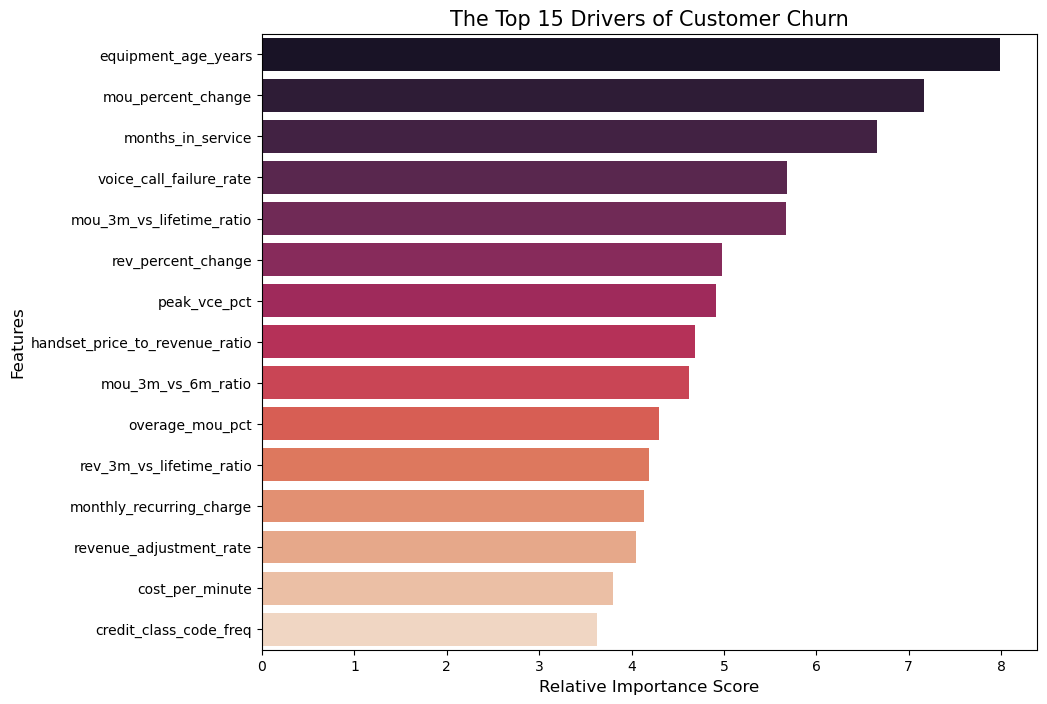

In [84]:
# Feature importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances.head(15), palette='rocket')

plt.title('The Top 15 Drivers of Customer Churn', fontsize=15)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)


Confusion Matrix (Last Fold):
[[2698 7390]
 [ 979 8933]]


<Figure size 800x600 with 0 Axes>

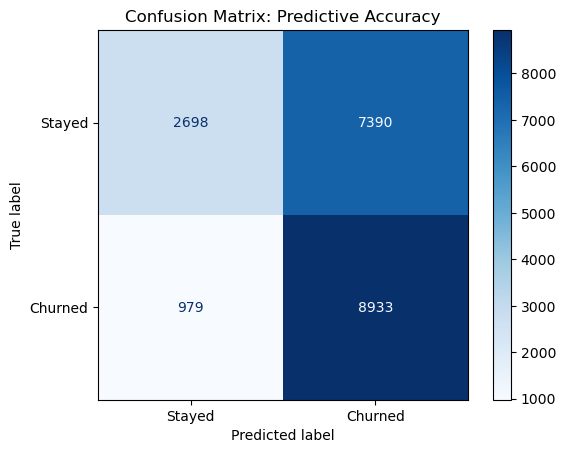

In [85]:
# Confusion Matrix
cm = confusion_matrix(y_valid, y_pred)

print("\nConfusion Matrix (Last Fold):")
print(cm)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Predictive Accuracy')
plt.show()

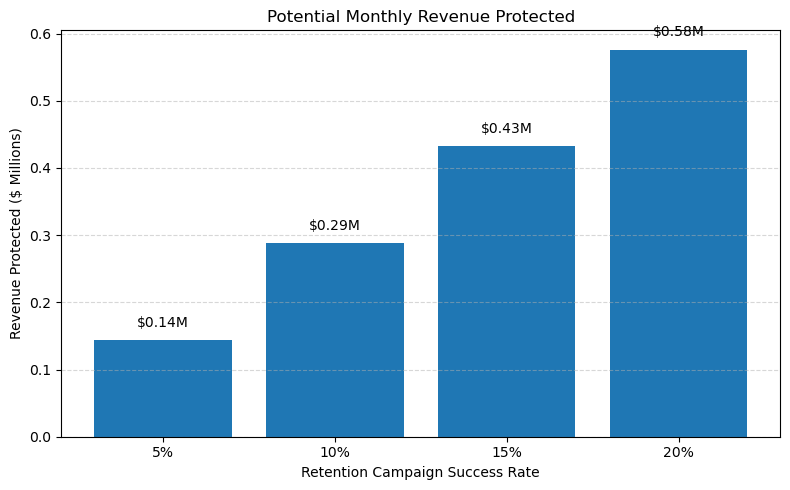

In [87]:
# estimated revenue protected
revenue_at_risk = 2.88  #revenue_risk

retention_rates = [0.05, 0.10, 0.15, 0.20]

monthly_revenue_saved = [
    revenue_at_risk * r for r in retention_rates
]

labels = ['5%', '10%', '15%', '20%']

plt.figure(figsize=(8,5))
bars = plt.bar(labels, monthly_revenue_saved)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'${height:.2f}M',
        ha='center'
    )

plt.title('Potential Monthly Revenue Protected')
plt.xlabel('Retention Campaign Success Rate')
plt.ylabel('Revenue Protected ($ Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()